# 05. Ablation Study

## 0. Setup

In [1]:
import csv
import random
import re
import json
import time
from pathlib import Path
from collections import defaultdict

import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.checkpoint import checkpoint  # memory fix -- see VisualEncoderToggle.forward
from sklearn.metrics import f1_score, roc_auc_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

MANIFEST = Path('~/Desktop/convscript/Code/Manifest/manifests/master_manifest.csv').expanduser()
ROOT     = Path('~/Desktop/Thesis/TR-6').expanduser()  # TR-6 raw dataset
GAS_NORM = Path('~/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json').expanduser()
RUNS     = Path('~/Desktop/convscript/runs').expanduser()

DEVICE = (
    'mps'  if torch.backends.mps.is_available() else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
)
print(f'Device: {DEVICE}')

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import math

ABLATION_OUT = RUNS / "04_fusion_model"
ABLATION_OUT.mkdir(parents=True, exist_ok=True)


Device: mps


In [2]:
FRUIT_LIST   = ['Banana', 'Carrot', 'Guava', 'Indian_Gooseberry', 'Mango', 'Tomato']
FRUIT_TO_IDX = {f: i for i, f in enumerate(FRUIT_LIST)}
FRUIT_COLORS = {'Banana':'#F5C518','Carrot':'#FF6B35','Guava':'#7BC67E',
                'Indian_Gooseberry':'#9B59B6','Mango':'#FF8C00','Tomato':'#E74C3C'}
SESSION_TO_IDX = {'morning':0,'afternoon':1,'evening':2}
LABEL_TO_IDX   = {'not_spoiled':0,'spoiled':1}
IMAGE_SIZE     = 224
IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]
SESSION_HOUR_BUCKETS = {'morning':(5,11),'afternoon':(12,16),'evening':(16,19)}
IR_PATTERN   = re.compile(r'(\d{8})_(\d{6})_([\d.]+)C_([\d.]+)C\.jpg$', re.IGNORECASE)
SRGB_PATTERN = re.compile(r'^(\d{8})_(\d{6})[^/]*\.jpg$', re.IGNORECASE)
NUM_FRUITS   = len(FRUIT_TO_IDX)
ABLATIONS    = ['no_cross_attn','no_dropout','no_fruit_emb','no_recon','no_session_idx','no_gas_norm']
THRESHOLDS_TO_SWEEP = [t/100 for t in range(10, 91)]

SUBSETS = [
    {'name':'RGB only',       'rgb':True,  'ir':False,'gas':False},
    {'name':'IR only',        'rgb':False, 'ir':True, 'gas':False},
    {'name':'Gas only',       'rgb':False, 'ir':False,'gas':True},
    {'name':'RGB + IR',       'rgb':True,  'ir':True, 'gas':False},
    {'name':'RGB + Gas',      'rgb':True,  'ir':False,'gas':True},
    {'name':'IR + Gas',       'rgb':False, 'ir':True, 'gas':True},
    {'name':'All modalities', 'rgb':True,  'ir':True, 'gas':True},
]
N_AVAILABLE = {'RGB only':1,'IR only':1,'Gas only':1,
               'RGB + IR':2,'RGB + Gas':2,'IR + Gas':2,'All modalities':3}

def safe_float(val, default=0.0):
    try: return float(val)
    except: return default

def hour_to_session(hour):
    for name,(lo,hi) in SESSION_HOUR_BUCKETS.items():
        if lo<=hour<hi: return name
    return 'unknown'

def find_ir_folder(base):
    for name in ['IR_fusion_images','IR_Fusion_images','ir_fusion_images']:
        p=base/name
        if p.exists(): return p
    return base/'IR_fusion_images'

def group_images_by_session(folder, pattern):
    result=defaultdict(lambda:defaultdict(list))
    if not folder.exists(): return {}
    for f in sorted(folder.iterdir()):
        m=pattern.search(f.name)
        if not m: continue
        session=hour_to_session(int(m.group(2)[:2]))
        if session!='unknown': result[m.group(1)][session].append(f)
    return dict(result)

print('Constants ready.')


Constants ready.


In [3]:
def get_rgb_transform(train: bool):
    if train:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(), transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


def get_ir_transform(train: bool):
    if train:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(), transforms.RandomRotation(15),
            transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


In [4]:
class TrimodalDataset(Dataset):
    def __init__(self,manifest_path,root,train=True,modality_dropout_prob=0.3,
                 exclude_flagged=True,split=None,gas_norm_stats_path=None,
                 cache_images=True,shared_pixel_cache=None,gas_only=False):
        self.root=Path(root);self.train=train;self.modality_dropout_prob=modality_dropout_prob
        self.rgb_transform=get_rgb_transform(train);self.ir_transform=get_ir_transform(train)
        self.gas_norm_stats=None
        if gas_norm_stats_path:
            with open(gas_norm_stats_path) as f: self.gas_norm_stats=json.load(f)['stats']
            print(f'Gas norm stats loaded from {gas_norm_stats_path}')
        with open(manifest_path,newline='') as f: all_rows=list(csv.DictReader(f))
        if exclude_flagged: all_rows=[r for r in all_rows if r.get('exclude','').strip().lower()!='true']
        if split: all_rows=[r for r in all_rows if r.get('split','').strip().lower()==split.lower()]
        self.samples=[];self._build_samples(all_rows)
        self.gas_only=gas_only;self._image_cache={}
        if not gas_only: self._build_image_index()
        self._pixel_cache={}
        if not gas_only:
            if shared_pixel_cache is not None:
                self._pixel_cache=shared_pixel_cache
                print(f'  Using shared image cache ({len(self._pixel_cache)} images).',flush=True)
            elif cache_images: self._warmup_pixel_cache()
        print(f'TrimodalDataset: {len(self.samples)} sessions ({"train" if train else "val/test"}, split={split})')

    def _build_samples(self,rows):
        for row in rows:
            fruit=row['fruit'];label=row['label'];date_str=row['actual_date']
            global_day=int(row['corrected_day_index'])
            days_until=safe_float(row.get('days_until_spoilage',''),default=-1.0)
            for session in ['morning','afternoon','evening']:
                si=SESSION_TO_IDX[session]
                ir_avail=safe_float(row.get(f'ir_{session}_count',0))>0
                ir_tmin=safe_float(row.get(f'ir_{session}_tmin',''),0.0)
                ir_tmax=safe_float(row.get(f'ir_{session}_tmax',''),0.0)
                ir_trange=safe_float(row.get(f'ir_{session}_trange',''),0.0)
                srgb_avail=safe_float(row.get(f'srgb_{session}_count',0))>0
                gas_avail=row.get(f'methane_{session}_present','').strip().upper()=='TRUE'
                mean_ppm=safe_float(row.get(f'methane_{session}_ppm',''),0.0)
                std_ppm=safe_float(row.get(f'methane_{session}_std',''),0.0)
                left_ppm=safe_float(row.get(f'methane_{session}_left',''),0.0)
                right_ppm=safe_float(row.get(f'methane_{session}_right',''),0.0)
                if not ir_avail and not srgb_avail and not gas_avail: continue
                self.samples.append({'fruit':fruit,'label':label,'actual_date':date_str,
                    'corrected_day_index':global_day,'session':session,'session_idx':si,
                    'fruit_idx':FRUIT_TO_IDX.get(fruit,0),'label_idx':LABEL_TO_IDX.get(label,0),
                    'days_until_spoilage':days_until,'ir_tmin':ir_tmin,'ir_tmax':ir_tmax,
                    'ir_trange':ir_trange,'gas_mean':mean_ppm,'gas_std':std_ppm,
                    'gas_left':left_ppm,'gas_right':right_ppm,'gas_asym':abs(left_ppm-right_ppm),
                    'rgb_available':srgb_avail,'ir_available':ir_avail,'gas_available':gas_avail})

    def _build_image_index(self):
        label_map={'not_spoiled':'Not_spoiled','spoiled':'Spoiled'}
        for fruit in FRUIT_LIST:
            for lk,lf in label_map.items():
                base=self.root/'Classified'/fruit/lf
                for d,ss in group_images_by_session(base/'sRGB_images',SRGB_PATTERN).items():
                    for s,ps in ss.items():
                        self._image_cache.setdefault((fruit,lk,d,s),{'rgb':[],'ir':[]})['rgb']=ps
                for d,ss in group_images_by_session(find_ir_folder(base),IR_PATTERN).items():
                    for s,ps in ss.items():
                        self._image_cache.setdefault((fruit,lk,d,s),{'rgb':[],'ir':[]})['ir']=ps
        banana_ir=group_images_by_session(find_ir_folder(self.root/'Normal'/'Banana'),IR_PATTERN)
        spoiled_dates={date for (fr,lb,date,_) in self._image_cache if fr=='Banana' and lb=='spoiled'}
        for d,ss in banana_ir.items():
            if d in spoiled_dates:
                for s,ps in ss.items():
                    key=('Banana','spoiled',d,s)
                    self._image_cache.setdefault(key,{'rgb':[],'ir':[]})
                    if not self._image_cache[key].get('ir'): self._image_cache[key]['ir']=ps

    def _load_cached(self,path,transform):
        cached=self._pixel_cache.get(str(path))
        if cached is not None:
            return transform(Image.fromarray(cached.permute(1,2,0).numpy()))
        return load_image(path,transform)

    def _warmup_pixel_cache(self):
        all_paths=set()
        for v in self._image_cache.values():
            all_paths.update(v.get('rgb',[]));all_paths.update(v.get('ir',[]))
        total=len(all_paths)
        print(f'  Warming up image cache: {total} images...',flush=True)
        for i,path in enumerate(all_paths):
            if str(path) in self._pixel_cache: continue
            try:
                img=self.rgb_transform.transforms[0](Image.open(path).convert('RGB'))
                self._pixel_cache[str(path)]=torch.from_numpy(np.array(img)).permute(2,0,1)
            except: pass
            if (i+1)%500==0 or (i+1)==total:
                mb=sum(t.nbytes for t in self._pixel_cache.values())/(1024**2)
                print(f'  {i+1}/{total} cached  ({mb:.0f} MB used)',flush=True)
        print(f'  Cache ready. {len(self._pixel_cache)} images in RAM.',flush=True)

    def _normalize_gas(self,fruit,session,mean_ppm,std_ppm,left_ppm,right_ppm):
        if self.gas_norm_stats is None: return mean_ppm,std_ppm,left_ppm,right_ppm
        s=self.gas_norm_stats.get(fruit,{}).get(session,{})
        def norm(val,key): st=s.get(key,{'mean':0.,'std':1.}); return (val-st['mean'])/st['std']
        return norm(mean_ppm,'mean_ppm'),norm(std_ppm,'std_ppm'),norm(left_ppm,'left_ppm'),norm(right_ppm,'right_ppm')

    def _apply_dropout(self,rgb_avail,ir_avail,gas_avail):
        if not self.train: return rgb_avail,ir_avail,gas_avail
        while True:
            r=rgb_avail and (random.random()>self.modality_dropout_prob)
            i=ir_avail  and (random.random()>self.modality_dropout_prob)
            g=gas_avail and (random.random()>self.modality_dropout_prob)
            if r or i or g: return r,i,g

    def __len__(self): return len(self.samples)

    def __getitem__(self,idx):
        s=self.samples[idx]
        fruit=s['fruit'];label=s['label'];date_str=s['actual_date']
        session=s['session'];si=s['session_idx']
        rgb_avail,ir_avail,gas_avail=self._apply_dropout(s['rgb_available'],s['ir_available'],s['gas_available'])
        cached=self._image_cache.get((fruit,label,date_str,session),{'rgb':[],'ir':[]})
        if not self.gas_only and rgb_avail and cached['rgb']:
            rgb_tensors=torch.stack([self._load_cached(p,self.rgb_transform) for p in cached['rgb']])
        else: rgb_avail=False;rgb_tensors=torch.zeros(1,3,IMAGE_SIZE,IMAGE_SIZE)
        if not self.gas_only and ir_avail and cached['ir']:
            ir_tensors=torch.stack([self._load_cached(p,self.ir_transform) for p in cached['ir']])
        else: ir_avail=False;ir_tensors=torch.zeros(1,3,IMAGE_SIZE,IMAGE_SIZE)
        ir_scalars=torch.tensor([s['ir_tmin'],s['ir_tmax'],s['ir_trange']],dtype=torch.float32) if ir_avail else torch.zeros(3)
        if gas_avail:
            m,sd,l,r=self._normalize_gas(fruit,session,s['gas_mean'],s['gas_std'],s['gas_left'],s['gas_right'])
            gas=torch.tensor([m,sd,l,r,abs(l-r),float(si)/2.],dtype=torch.float32)
        else: gas=torch.zeros(6)
        return {'rgb_images':rgb_tensors,'ir_images':ir_tensors,'ir_scalars':ir_scalars,'gas':gas,
                'rgb_available':torch.tensor(rgb_avail,dtype=torch.bool),
                'ir_available':torch.tensor(ir_avail,dtype=torch.bool),
                'gas_available':torch.tensor(gas_avail,dtype=torch.bool),
                'fruit_idx':torch.tensor(s['fruit_idx'],dtype=torch.long),
                'session_idx':torch.tensor(si,dtype=torch.long),
                'label':torch.tensor(s['label_idx'],dtype=torch.long),
                'days_until_spoilage':torch.tensor(s['days_until_spoilage'],dtype=torch.float32),
                'fruit':fruit,'actual_date':date_str,'corrected_day_index':s['corrected_day_index']}


class NoSessionIdxDataset(TrimodalDataset):
    def __getitem__(self,idx):
        item=super().__getitem__(idx)
        gas=item['gas'].clone(); gas[5]=0.0; item['gas']=gas
        return item

class NoGasNormDataset(TrimodalDataset):
    def __getitem__(self,idx):
        saved=self.gas_norm_stats; self.gas_norm_stats=None
        item=super().__getitem__(idx); self.gas_norm_stats=saved
        return item


def trimodal_collate(batch):
    return {'rgb_images':[s['rgb_images'] for s in batch],'ir_images':[s['ir_images'] for s in batch],
            'ir_scalars':torch.stack([s['ir_scalars'] for s in batch]),
            'gas':torch.stack([s['gas'] for s in batch]),
            'rgb_available':torch.stack([s['rgb_available'] for s in batch]),
            'ir_available':torch.stack([s['ir_available'] for s in batch]),
            'gas_available':torch.stack([s['gas_available'] for s in batch]),
            'fruit_idx':torch.stack([s['fruit_idx'] for s in batch]),
            'session_idx':torch.stack([s['session_idx'] for s in batch]),
            'label':torch.stack([s['label'] for s in batch]),
            'days_until_spoilage':torch.stack([s['days_until_spoilage'] for s in batch]),
            'fruit':[s['fruit'] for s in batch],'actual_date':[s['actual_date'] for s in batch],
            'corrected_day_index':[s['corrected_day_index'] for s in batch]}

print('Dataset ready.')


Dataset ready.


In [5]:
class DayLevelSequenceDataset(Dataset):
    def __init__(self, manifest_path=MANIFEST, root=ROOT, split="train",
                 gas_norm_stats_path=GAS_NORM, shared_pixel_cache=None):
        base = TrimodalDataset(
            manifest_path, root, train=False, modality_dropout_prob=0.0,
            split=split, gas_norm_stats_path=gas_norm_stats_path, cache_images=True,
            shared_pixel_cache=shared_pixel_cache,
        )
        self._pixel_cache = base._pixel_cache
        print(f"DayLevelSequenceDataset ({split}): wrapping {len(base)} sessions")
        day_groups = defaultdict(list)
        for i in range(len(base)):
            item = base[i]
            key = (item["fruit"], int(item["label"].item()), int(item["corrected_day_index"]))
            day_groups[key].append(item)
        day_entries = {}
        for (fruit, label, day_idx), sessions in day_groups.items():
            sessions.sort(key=lambda s: int(s["session_idx"].item()))
            rgb_img, ir_img = None, None
            for s in sessions:
                if rgb_img is None and bool(s["rgb_available"].item()) and len(s["rgb_images"]) > 0:
                    rgb_img = s["rgb_images"][0]
                if ir_img is None and bool(s["ir_available"].item()) and len(s["ir_images"]) > 0:
                    ir_img = s["ir_images"][0]
            gas_vals = [s["gas"] for s in sessions if bool(s["gas_available"].item())]
            gas_avail = len(gas_vals) > 0
            gas_vec = torch.stack(gas_vals).mean(dim=0) if gas_avail else torch.zeros(6)
            day_entries.setdefault((fruit, label), []).append({
                "day_idx": day_idx, "rgb_img": rgb_img, "ir_img": ir_img,
                "gas_vec": gas_vec, "gas_avail": gas_avail,
                "fruit_idx": sessions[0]["fruit_idx"], "label": sessions[0]["label"],
                "days_until": sessions[0]["days_until_spoilage"],
            })
        self.trajectories = []
        for (fruit, label), days in day_entries.items():
            days.sort(key=lambda d: d["day_idx"])
            last_observed_idx = None
            for d in days:
                d["delta"] = 0.0 if last_observed_idx is None else float(d["day_idx"] - last_observed_idx)
                if d["gas_avail"]:
                    last_observed_idx = d["day_idx"]
            self.trajectories.append({"fruit": fruit, "label": label, "days": days})
        n_days_total = sum(len(t["days"]) for t in self.trajectories)
        print(f"  {len(self.trajectories)} trajectories, {n_days_total} total day-entries")

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        traj = self.trajectories[idx]["days"]
        T = len(traj)
        blank_rgb = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        blank_ir  = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        rgb_seq   = torch.stack([d["rgb_img"] if d["rgb_img"] is not None else blank_rgb for d in traj])
        ir_seq    = torch.stack([d["ir_img"]  if d["ir_img"]  is not None else blank_ir  for d in traj])
        rgb_avail = torch.tensor([d["rgb_img"] is not None for d in traj], dtype=torch.bool)
        ir_avail  = torch.tensor([d["ir_img"]  is not None for d in traj], dtype=torch.bool)
        gas_seq   = torch.stack([d["gas_vec"] for d in traj])
        gas_mask  = torch.tensor([d["gas_avail"] for d in traj], dtype=torch.float32)
        gas_delta = torch.tensor([d["delta"] for d in traj], dtype=torch.float32)
        return {
            "rgb_seq": rgb_seq, "ir_seq": ir_seq, "rgb_avail": rgb_avail, "ir_avail": ir_avail,
            "gas_seq": gas_seq, "gas_mask": gas_mask, "gas_delta": gas_delta, "T": T,
            "fruit_idx": traj[0]["fruit_idx"], "label": traj[-1]["label"],
            "days_until": traj[-1]["days_until"],
        }


def day_sequence_collate(batch):
    max_T = max(b["T"] for b in batch)
    B = len(batch)
    rgb  = torch.zeros(B, max_T, 3, IMAGE_SIZE, IMAGE_SIZE)
    ir   = torch.zeros(B, max_T, 3, IMAGE_SIZE, IMAGE_SIZE)
    rgb_avail = torch.zeros(B, max_T, dtype=torch.bool)
    ir_avail  = torch.zeros(B, max_T, dtype=torch.bool)
    gas  = torch.zeros(B, max_T, 6)
    gas_mask  = torch.zeros(B, max_T)
    gas_delta = torch.zeros(B, max_T)
    pad_mask  = torch.ones(B, max_T, dtype=torch.bool)
    fruit_idx = torch.zeros(B, dtype=torch.long)
    label     = torch.zeros(B, dtype=torch.long)
    days_until = torch.zeros(B, dtype=torch.float32)
    for i, b in enumerate(batch):
        T = b["T"]
        rgb[i, :T] = b["rgb_seq"]; ir[i, :T] = b["ir_seq"]
        rgb_avail[i, :T] = b["rgb_avail"]; ir_avail[i, :T] = b["ir_avail"]
        gas[i, :T] = b["gas_seq"]; gas_mask[i, :T] = b["gas_mask"]; gas_delta[i, :T] = b["gas_delta"]
        pad_mask[i, :T] = False
        fruit_idx[i] = b["fruit_idx"]; label[i] = b["label"]; days_until[i] = b["days_until"]
    return {"rgb_seq": rgb, "ir_seq": ir, "rgb_avail": rgb_avail, "ir_avail": ir_avail,
            "gas_seq": gas, "gas_mask": gas_mask, "gas_delta": gas_delta, "pad_mask": pad_mask,
            "fruit_idx": fruit_idx, "label": label, "days_until": days_until}


In [6]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        hidden = max(channels // reduction, 8)
        self.mlp = nn.Sequential(nn.Conv2d(channels, hidden, 1, bias=False), nn.ReLU(inplace=True),
                                  nn.Conv2d(hidden, channels, 1, bias=False))

    def forward(self, x):
        return torch.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)

    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out, _ = x.max(dim=1, keepdim=True)
        return torch.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.channel_attn = ChannelAttention(channels, reduction)
        self.spatial_attn = SpatialAttention(spatial_kernel)

    def forward(self, x):
        x = x * self.channel_attn(x)
        sa = self.spatial_attn(x)
        return x * sa, sa


BACKBONE_FEATURE_DIMS = {"efficientnet_b0": 1280, "resnet18": 512}


def build_cnn_backbone(name: str):
    if name == "efficientnet_b0":
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        backbone = base.features
    elif name == "resnet18":
        base = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        backbone = nn.Sequential(*list(base.children())[:-2])
    else:
        raise ValueError(f"Unknown backbone: {name}")
    return backbone, BACKBONE_FEATURE_DIMS[name]


class GRUDCell(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, x_mean=None):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        if x_mean is None:
            x_mean = [0.0] * input_dim
        self.register_buffer("x_mean", torch.as_tensor(x_mean, dtype=torch.float32))
        self.W_gamma_x = nn.Linear(1, input_dim)
        self.W_gamma_h = nn.Linear(1, hidden_dim)
        self.gru_cell = nn.GRUCell(input_dim * 2, hidden_dim)

    def forward(self, x_t, m_t, delta_t, x_last, h_prev):
        gamma_x = torch.exp(-torch.clamp(self.W_gamma_x(delta_t), min=0.0))
        x_bar = self.x_mean.unsqueeze(0).expand_as(x_t)
        x_hat = m_t * x_t + (1 - m_t) * (gamma_x * x_last + (1 - gamma_x) * x_bar)
        gamma_h = torch.exp(-torch.clamp(self.W_gamma_h(delta_t), min=0.0))
        h_t = self.gru_cell(torch.cat([x_hat, m_t], dim=-1), gamma_h * h_prev)
        return h_t, x_hat


In [7]:
class VisualEncoderToggle(nn.Module):
    def __init__(self, backbone_name="efficientnet_b0", freeze_backbone=True,
                 use_cbam=True, chunk_size=8):
        super().__init__()
        self.use_cbam = use_cbam
        self.backbone_name = backbone_name
        self.chunk_size = chunk_size
        self.backbone, self.feature_dim = build_cnn_backbone(backbone_name)
        if use_cbam:
            self.cbam = CBAM(self.feature_dim)
        self.pool = nn.AdaptiveAvgPool2d(1)
        if freeze_backbone:
            self.freeze_backbone()

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def unfreeze_last_n_layers(self, n: int):
        self.freeze_backbone()
        for child in list(self.backbone.children())[-n:]:
            for p in child.parameters():
                p.requires_grad = True

    def forward(self, seq: torch.Tensor):
        B, T, C, H, W = seq.shape
        flat = seq.reshape(B * T, C, H, W)
        feats_list = []
        needs_ckpt = (torch.is_grad_enabled()
                      and any(p.requires_grad for p in self.backbone.parameters()))
        for start in range(0, flat.shape[0], self.chunk_size):
            chunk = flat[start:start + self.chunk_size]
            if needs_ckpt:
                feat_map = checkpoint(self.backbone, chunk, use_reentrant=False)
            else:
                feat_map = self.backbone(chunk)
            if self.use_cbam:
                feat_map, _ = self.cbam(feat_map)
            feats_list.append(self.pool(feat_map).flatten(1))
        feats = torch.cat(feats_list, dim=0).view(B, T, -1)
        return feats


In [8]:
class GasGRUDSequenceEncoder(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, x_mean=None):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell = GRUDCell(input_dim, hidden_dim, x_mean)

    def forward(self, gas_seq, gas_mask, gas_delta, pad_mask):
        B, T, D = gas_seq.shape
        device = gas_seq.device
        h = torch.zeros(B, self.hidden_dim, device=device)
        x_last = torch.zeros(B, D, device=device)
        h_seq = []
        for t in range(T):
            x_t = gas_seq[:, t]
            m_t = gas_mask[:, t].unsqueeze(-1).expand(-1, D)
            delta_t = gas_delta[:, t].unsqueeze(-1)
            valid_t = (~pad_mask[:, t]).float().unsqueeze(-1)
            h_new, x_hat = self.cell(x_t, m_t, delta_t, x_last, h)
            h = valid_t * h_new + (1 - valid_t) * h
            x_last = torch.where(m_t.bool(), x_t, x_last)
            h_seq.append(h)
        return torch.stack(h_seq, dim=1)


class GasEncoderMeanImpute(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.gru = nn.GRU(input_dim + 1, hidden_dim, batch_first=True)

    def forward(self, gas_seq, gas_mask, gas_delta, pad_mask):
        imputed = gas_seq * gas_mask.unsqueeze(-1)   # missing entries -> 0 (the effective mean)
        gru_input = torch.cat([imputed, gas_mask.unsqueeze(-1)], dim=-1)
        lengths = (~pad_mask).sum(dim=1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(gru_input, lengths, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.gru(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=gas_seq.shape[1])
        return out   # (B,T,hidden_dim) -- same interface as GasGRUDSequenceEncoder


In [9]:
class FusionToggle(nn.Module):
    def __init__(self, d_model=256, num_heads=4, dropout=0.1, use_cross_attn=True):
        super().__init__()
        self.use_cross_attn = use_cross_attn
        if use_cross_attn:
            self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads,
                                              dropout=dropout, batch_first=True)
            self.norm = nn.LayerNorm(d_model)
        else:
            self.concat_proj = nn.Sequential(
                nn.Linear(d_model * 3, d_model), nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout),
            )

    def forward(self, rgb_t, ir_t, gas_t, rgb_avail_t, ir_avail_t, gas_avail_t):
        if self.use_cross_attn:
            tokens = torch.stack([rgb_t, ir_t, gas_t], dim=1)
            avail  = torch.stack([rgb_avail_t, ir_avail_t, gas_avail_t], dim=1)
            key_padding_mask = ~avail
            fully_missing = key_padding_mask.all(dim=1)
            if fully_missing.any():
                key_padding_mask = key_padding_mask.clone()
                key_padding_mask[fully_missing] = False
            attended, attn_w = self.attn(tokens, tokens, tokens, key_padding_mask=key_padding_mask,
                                         need_weights=True, average_attn_weights=True)
            out = self.norm(tokens + attended)
            return out.mean(dim=1), attn_w
        else:
            concat = torch.cat([rgb_t, ir_t, gas_t], dim=-1)
            return self.concat_proj(concat), None


In [10]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.shape[1]]


class TemporalTransformer(nn.Module):
    def __init__(self, d_model=256, nhead=4, num_layers=2, dim_feedforward=512,
                 dropout=0.1, max_len=100):
        super().__init__()
        self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
                                           dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)

    def forward(self, z_seq: torch.Tensor, pad_mask: torch.Tensor):
        z_seq = self.pos_enc(z_seq)
        return self.encoder(z_seq, src_key_padding_mask=pad_mask)


class LSTMTemporalModule(nn.Module):
    def __init__(self, d_model=256, hidden_dim=256, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(d_model, hidden_dim, num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.out_proj = nn.Linear(hidden_dim, d_model) if hidden_dim != d_model else nn.Identity()

    def forward(self, z_seq: torch.Tensor, pad_mask: torch.Tensor):
        lengths = (~pad_mask).sum(dim=1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(z_seq, lengths, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=z_seq.shape[1])
        return self.out_proj(out)   # (B,T,d_model) -- same interface as TemporalTransformer


def gather_last_valid(H: torch.Tensor, pad_mask: torch.Tensor):
    device = H.device
    lengths = (~pad_mask).sum(dim=1)
    last_idx = (lengths - 1).clamp(min=0)
    B = H.shape[0]
    return H[torch.arange(B, device=device), last_idx], last_idx


In [11]:
class UncertaintyWeightedLoss(nn.Module):
    def __init__(self, n_tasks: int = 3):
        super().__init__()
        self.log_sigma = nn.Parameter(torch.zeros(n_tasks))

    def forward(self, losses: list):
        total = 0.0
        for i, L_i in enumerate(losses):
            precision = torch.exp(-2 * self.log_sigma[i])
            total = total + 0.5 * precision * L_i + self.log_sigma[i]
        return total

    def get_sigmas(self):
        return torch.exp(self.log_sigma).detach().cpu().numpy()


In [12]:
ABLATION_CONFIGS = {
    "baseline_a_early": {
        "fusion_type": "early", "use_cbam": False, "use_cross_attn": False,
        "temporal_type": "lstm", "missing_handling": "mean",
    },
    "baseline_b_late": {
        "fusion_type": "late", "use_cbam": False, "use_cross_attn": False,
        "temporal_type": "lstm", "missing_handling": "mean",
    },
    "ablation_1_no_cbam": {
        "fusion_type": "intermediate", "use_cbam": False, "use_cross_attn": True,
        "temporal_type": "transformer", "missing_handling": "grud",
    },
    "ablation_2_no_cross_attn": {
        "fusion_type": "intermediate", "use_cbam": True, "use_cross_attn": False,
        "temporal_type": "transformer", "missing_handling": "grud",
    },
    "ablation_3_lstm_not_transformer": {
        "fusion_type": "intermediate", "use_cbam": True, "use_cross_attn": True,
        "temporal_type": "lstm", "missing_handling": "grud",
    },
    "ablation_4_mean_impute_not_grud": {
        "fusion_type": "intermediate", "use_cbam": True, "use_cross_attn": True,
        "temporal_type": "transformer", "missing_handling": "mean",
    },
    "full_model": {
        "fusion_type": "intermediate", "use_cbam": True, "use_cross_attn": True,
        "temporal_type": "transformer", "missing_handling": "grud",
    },
}

class AblationModel(nn.Module):
    def __init__(self, config: dict, d_model=256, backbone_name="efficientnet_b0", gas_hidden=64,
                 num_heads=4, temporal_layers=2, dropout=0.1, cls_dropout=0.3,
                 freeze_visual_backbone=True):
        super().__init__()
        self.config = config
        self.d_model = d_model
        self.fusion_type = config["fusion_type"]

        self.rgb_encoder = VisualEncoderToggle(backbone_name, freeze_visual_backbone, use_cbam=config["use_cbam"])
        self.ir_encoder  = VisualEncoderToggle(backbone_name, freeze_visual_backbone, use_cbam=config["use_cbam"])
        if config["missing_handling"] == "grud":
            self.gas_encoder = GasGRUDSequenceEncoder(input_dim=6, hidden_dim=gas_hidden)
        else:
            self.gas_encoder = GasEncoderMeanImpute(input_dim=6, hidden_dim=gas_hidden)

        self.rgb_proj = nn.Sequential(nn.Linear(self.rgb_encoder.feature_dim, d_model),
                                       nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
        self.ir_proj  = nn.Sequential(nn.Linear(self.ir_encoder.feature_dim, d_model),
                                       nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
        self.gas_proj = nn.Sequential(nn.Linear(gas_hidden, d_model),
                                       nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))

        def make_temporal():
            if config["temporal_type"] == "transformer":
                return TemporalTransformer(d_model=d_model, nhead=num_heads,
                                           num_layers=temporal_layers, dropout=dropout)
            return LSTMTemporalModule(d_model=d_model, hidden_dim=d_model, dropout=dropout)

        def make_heads():
            cls = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(), nn.Dropout(cls_dropout), nn.Linear(128, 2))
            reg = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(), nn.Dropout(cls_dropout),
                                nn.Linear(128, 1), nn.ReLU())
            return cls, reg

        if self.fusion_type == "intermediate":
            self.fusion = FusionToggle(d_model=d_model, num_heads=num_heads, dropout=dropout,
                                       use_cross_attn=config["use_cross_attn"])
            self.temporal = make_temporal()
            self.cls_head, self.reg_head = make_heads()

        elif self.fusion_type == "early":
            self.early_proj = nn.Sequential(nn.Linear(d_model * 3, d_model),
                                            nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
            self.temporal = make_temporal()
            self.cls_head, self.reg_head = make_heads()

        elif self.fusion_type == "late":
            self.temporal_rgb = make_temporal()
            self.temporal_ir  = make_temporal()
            self.temporal_gas = make_temporal()
            self.cls_head_rgb, self.reg_head_rgb = make_heads()
            self.cls_head_ir,  self.reg_head_ir  = make_heads()
            self.cls_head_gas, self.reg_head_gas = make_heads()

        else:
            raise ValueError(f"Unknown fusion_type: {self.fusion_type}")
        self.gas_recon_head = nn.Sequential(nn.Linear(d_model * 2, 128), nn.ReLU(),
                                            nn.Dropout(cls_dropout), nn.Linear(128, 6))

    def freeze_visual_backbones(self):
        self.rgb_encoder.freeze_backbone(); self.ir_encoder.freeze_backbone()

    def unfreeze_visual_last_n(self, n: int):
        self.rgb_encoder.unfreeze_last_n_layers(n); self.ir_encoder.unfreeze_last_n_layers(n)

    def unfreeze_visual_full(self):
        self.rgb_encoder.unfreeze_backbone(); self.ir_encoder.unfreeze_backbone()

    def forward(self, batch: dict):
        device = next(self.parameters()).device
        rgb_seq = batch["rgb_seq"].to(device); ir_seq = batch["ir_seq"].to(device)
        rgb_avail = batch["rgb_avail"].to(device); ir_avail = batch["ir_avail"].to(device)
        gas_seq = batch["gas_seq"].to(device); gas_mask = batch["gas_mask"].to(device)
        gas_delta = batch["gas_delta"].to(device); pad_mask = batch["pad_mask"].to(device)
        B, T = rgb_avail.shape

        rgb_feat = self.rgb_encoder(rgb_seq)
        ir_feat  = self.ir_encoder(ir_seq)
        gas_feat = self.gas_encoder(gas_seq, gas_mask, gas_delta, pad_mask)

        rgb_proj = self.rgb_proj(rgb_feat) * rgb_avail.unsqueeze(-1).float()
        ir_proj  = self.ir_proj(ir_feat)  * ir_avail.unsqueeze(-1).float()
        gas_proj = self.gas_proj(gas_feat) * gas_mask.unsqueeze(-1)

        if self.fusion_type == "intermediate":
            rgb_flat = rgb_proj.reshape(B * T, -1)
            ir_flat  = ir_proj.reshape(B * T, -1)
            gas_flat = gas_proj.reshape(B * T, -1)
            rgb_av_flat = rgb_avail.reshape(B * T)
            ir_av_flat  = ir_avail.reshape(B * T)
            gas_av_flat = gas_mask.reshape(B * T).bool()
            z_flat, _ = self.fusion(rgb_flat, ir_flat, gas_flat, rgb_av_flat, ir_av_flat, gas_av_flat)
            z_seq = z_flat.reshape(B, T, -1)
            H = self.temporal(z_seq, pad_mask)
            H_T, last_idx = gather_last_valid(H, pad_mask)
            cls_logits = self.cls_head(H_T)
            reg_output = self.reg_head(H_T)

        elif self.fusion_type == "early":
            z_seq = self.early_proj(torch.cat([rgb_proj, ir_proj, gas_proj], dim=-1))
            H = self.temporal(z_seq, pad_mask)
            H_T, last_idx = gather_last_valid(H, pad_mask)
            cls_logits = self.cls_head(H_T)
            reg_output = self.reg_head(H_T)

        else:  # late
            H_rgb = self.temporal_rgb(rgb_proj, pad_mask)
            H_ir  = self.temporal_ir(ir_proj, pad_mask)
            H_gas = self.temporal_gas(gas_proj, pad_mask)
            HT_rgb, last_idx = gather_last_valid(H_rgb, pad_mask)
            HT_ir,  _        = gather_last_valid(H_ir,  pad_mask)
            HT_gas, _        = gather_last_valid(H_gas, pad_mask)

            logits_rgb = self.cls_head_rgb(HT_rgb); logits_ir = self.cls_head_ir(HT_ir); logits_gas = self.cls_head_gas(HT_gas)
            reg_rgb = self.reg_head_rgb(HT_rgb); reg_ir = self.reg_head_ir(HT_ir); reg_gas = self.reg_head_gas(HT_gas)

            rgb_av_last = rgb_avail[torch.arange(B, device=device), last_idx].float()
            ir_av_last  = ir_avail[torch.arange(B, device=device), last_idx].float()
            gas_av_last = gas_mask[torch.arange(B, device=device), last_idx]
            avail_stack = torch.stack([rgb_av_last, ir_av_last, gas_av_last], dim=1)   # (B,3)
            denom = avail_stack.sum(dim=1, keepdim=True).clamp(min=1.0)

            # Average LOGITS (not probabilities) -- see markdown note above.
            logits_stack = torch.stack([logits_rgb, logits_ir, logits_gas], dim=1)     # (B,3,2)
            cls_logits = (logits_stack * avail_stack.unsqueeze(-1)).sum(dim=1) / denom

            reg_stack = torch.stack([reg_rgb, reg_ir, reg_gas], dim=1).squeeze(-1)     # (B,3)
            reg_output = ((reg_stack * avail_stack).sum(dim=1) / denom.squeeze(-1)).unsqueeze(-1)

        rgb_last = rgb_proj[torch.arange(B, device=device), last_idx]
        ir_last  = ir_proj[torch.arange(B, device=device), last_idx]
        gas_recon = self.gas_recon_head(torch.cat([rgb_last, ir_last], dim=1))

        return {"cls_logits": cls_logits, "reg_output": reg_output, "gas_recon": gas_recon, "last_idx": last_idx}


In [13]:
THRESHOLDS_TO_SWEEP = [t / 100 for t in range(10, 91)]


def build_weighted_sampler(dataset):
    labels = [int(t["label"]) for t in dataset.trajectories]
    n_total = len(labels); n_spoiled = max(sum(labels), 1); n_fresh = max(n_total - sum(labels), 1)
    w_spoiled = n_total / (2 * n_spoiled); w_fresh = n_total / (2 * n_fresh)
    weights = [w_spoiled if l == 1 else w_fresh for l in labels]
    return WeightedRandomSampler(weights=weights, num_samples=n_total, replacement=True)


def calibrate_threshold(scores, labels, thresholds=None):
    if thresholds is None:
        thresholds = THRESHOLDS_TO_SWEEP
    if len(set(labels)) < 2:
        return 0.5, 0.0
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        preds = [1 if s >= t else 0 for s in scores]
        f = f1_score(labels, preds, average="binary", zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t, best_f1


def compute_metrics(all_labels, all_probs, all_preds, all_days_gt, all_days_pred):
    f1 = f1_score(all_labels, all_preds, average="binary", zero_division=0)
    try:
        auc = roc_auc_score(all_labels, np.array(all_probs)[:, 1])
    except ValueError:
        auc = float("nan")
    mae = mean_absolute_error(all_days_gt, all_days_pred)
    rmse = mean_squared_error(all_days_gt, all_days_pred) ** 0.5
    return {"f1": round(f1, 4), "auc": round(auc, 4), "mae": round(mae, 4), "rmse": round(rmse, 4)}


def compute_wt1_loss(out, batch, uncertainty_loss, cfg, device):
    labels = batch["label"].to(device)
    days   = batch["days_until"].to(device)
    class_weights = torch.tensor(cfg["cls_class_weights"], device=device)

    cls_loss = nn.CrossEntropyLoss(weight=class_weights)(out["cls_logits"], labels)
    reg_loss = nn.SmoothL1Loss()(out["reg_output"].squeeze(1), days)

    pad_mask = batch["pad_mask"].to(device)
    gas_mask = batch["gas_mask"].to(device)
    gas_seq  = batch["gas_seq"].to(device)
    last_idx = out["last_idx"]
    B = labels.shape[0]
    gas_avail_last = gas_mask[torch.arange(B, device=device), last_idx].bool()
    gas_true_last  = gas_seq[torch.arange(B, device=device), last_idx]

    if gas_avail_last.any():
        recon_loss = nn.MSELoss()(out["gas_recon"][gas_avail_last], gas_true_last[gas_avail_last])
    else:
        recon_loss = torch.zeros((), device=device)

    total_loss = uncertainty_loss([cls_loss, reg_loss, recon_loss])
    return total_loss, {"cls_loss": cls_loss.item(), "reg_loss": reg_loss.item(), "recon_loss": recon_loss.item()}


def get_cfg():
    return {
        "epochs": 30, "batch_size": 4, "lr": 1e-4, "lr_finetune": 1e-5, "weight_decay": 1e-4,
        "cls_class_weights": [1.0, 2.3], "device": DEVICE,
    }


def collect_probs_labels(model, uncertainty_loss, loader, cfg):
    model.eval(); uncertainty_loss.eval()
    device = cfg["device"]
    all_labels, all_probs, all_days_gt, all_days_pred = [], [], [], []
    with torch.no_grad():
        for batch in loader:
            out = model(batch)
            probs = torch.softmax(out["cls_logits"], dim=1).cpu().numpy()
            all_labels.extend(batch["label"].cpu().numpy().tolist())
            all_probs.extend(probs.tolist())
            all_days_gt.extend(batch["days_until"].cpu().numpy().tolist())
            all_days_pred.extend(out["reg_output"].squeeze(1).cpu().numpy().tolist())
    return np.array(all_probs), all_labels, all_days_gt, all_days_pred


def get_calibrated_threshold(model, uncertainty_loss, calib_loader, cfg):
    probs, labels, _, _ = collect_probs_labels(model, uncertainty_loss, calib_loader, cfg)
    threshold, _ = calibrate_threshold(probs[:, 1].tolist(), labels)
    return threshold


def run_epoch(model, uncertainty_loss, loader, optimizer, cfg, train=True, threshold=None):
    model.train() if train else model.eval()
    uncertainty_loss.train() if train else uncertainty_loss.eval()
    device = cfg["device"]
    total_loss = 0.0
    all_labels, all_probs, all_days_gt, all_days_pred = [], [], [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            out = model(batch)
            loss, parts = compute_wt1_loss(out, batch, uncertainty_loss, cfg, device)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(list(model.parameters()) + list(uncertainty_loss.parameters()), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()
            probs = torch.softmax(out["cls_logits"], dim=1).detach().cpu().numpy()
            all_labels.extend(batch["label"].cpu().numpy().tolist())
            all_probs.extend(probs.tolist())
            all_days_gt.extend(batch["days_until"].cpu().numpy().tolist())
            all_days_pred.extend(out["reg_output"].squeeze(1).detach().cpu().numpy().tolist())

    all_probs_arr = np.array(all_probs)
    if train:
        all_preds = all_probs_arr.argmax(axis=1).tolist()
        threshold_used = 0.5
    else:
        if threshold is None:
            raise ValueError(
            )
        threshold_used = threshold
        all_preds = (all_probs_arr[:, 1] >= threshold_used).astype(int).tolist()

    metrics = compute_metrics(all_labels, all_probs, all_preds, all_days_gt, all_days_pred)
    metrics["loss"] = round(total_loss / max(len(loader), 1), 4)
    metrics["threshold"] = threshold_used
    return metrics


## Backbone - ConvNeXt-Tiny

In [14]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights


def _infer_feature_dim(backbone, img_size=IMAGE_SIZE):
    backbone.eval()
    with torch.no_grad():
        dummy = torch.zeros(1, 3, img_size, img_size)
        out = backbone(dummy)
    return out.shape[1]


def build_cnn_backbone(name: str):
    if name == "efficientnet_b0":
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1, stochastic_depth_prob=0.0)
        backbone = base.features
        return backbone, BACKBONE_FEATURE_DIMS[name]
    elif name == "resnet18":
        base = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        backbone = nn.Sequential(*list(base.children())[:-2])
        return backbone, BACKBONE_FEATURE_DIMS[name]
    elif name == "convnext_tiny":
        base = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1, stochastic_depth_prob=0.0)
        backbone = base.features
    else:
        raise ValueError(f"Unknown backbone: {name}")

    feat_dim = _infer_feature_dim(backbone)
    BACKBONE_FEATURE_DIMS[name] = feat_dim
    return backbone, feat_dim


print("build_cnn_backbone ready (resnet18, efficientnet_b0, convnext_tiny).")


build_cnn_backbone ready (resnet18, efficientnet_b0, convnext_tiny).


In [15]:
class AblationModelCustomRGB(AblationModel):
    def __init__(self, config, **kwargs):
        rgb_encoder_factory = kwargs.pop("rgb_encoder_factory")
        super().__init__(config, **kwargs)
        d_model = self.d_model
        dropout = kwargs.get("dropout", 0.1)
        self.rgb_encoder = rgb_encoder_factory()
        self.rgb_proj = nn.Sequential(
            nn.Linear(self.rgb_encoder.feature_dim, d_model),
            nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout),
        )

    def unfreeze_visual_last_n(self, n: int):
        self.rgb_encoder.unfreeze_last_n_layers(n)
        self.ir_encoder.unfreeze_last_n_layers(n)

    def unfreeze_visual_full(self):
        self.rgb_encoder.unfreeze_backbone()
        self.ir_encoder.unfreeze_backbone()


print("AblationModelCustomRGB ready.")


AblationModelCustomRGB ready.


In [16]:
import torchvision.transforms.functional as TF
import traceback

In [17]:
from sklearn.metrics import accuracy_score, recall_score, r2_score


def compute_metrics(all_labels, all_probs, all_preds, all_days_gt, all_days_pred):
    f1 = f1_score(all_labels, all_preds, average="binary", zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    accuracy = accuracy_score(all_labels, all_preds)
    recall_per_class = recall_score(all_labels, all_preds, average=None, zero_division=0, labels=[0, 1])
    try:
        auc = roc_auc_score(all_labels, np.array(all_probs)[:, 1])
    except ValueError:
        auc = float("nan")
    mae = mean_absolute_error(all_days_gt, all_days_pred)
    rmse = mean_squared_error(all_days_gt, all_days_pred) ** 0.5
    try:
        r2 = r2_score(all_days_gt, all_days_pred)
    except ValueError:
        r2 = float("nan")
    return {
        "f1": round(f1, 4), "macro_f1": round(macro_f1, 4), "accuracy": round(accuracy, 4),
        "recall_not_spoiled": round(float(recall_per_class[0]), 4),
        "recall_spoiled": round(float(recall_per_class[1]), 4),
        "auc": round(auc, 4), "mae": round(mae, 4), "rmse": round(rmse, 4), "r2": round(r2, 4),
    }


In [18]:
class OfflineAugmentedDayLevelSequenceDataset(Dataset):
    def __init__(self, base_dataset, transform_type, n_copies=1):
        assert transform_type in ("flip_only", "rotation_only",
                                  "brightness_contrast_only", "flip_rotation")
        self.base = base_dataset
        self.transform_type = transform_type
        self.n_copies = n_copies

        self.index_map = []  
        for traj_idx in range(len(base_dataset)):
            self.index_map.append((traj_idx, 0))
            for copy_id in range(1, n_copies + 1):
                self.index_map.append((traj_idx, copy_id))

        self.trajectories = [base_dataset.trajectories[traj_idx] for traj_idx, _ in self.index_map]

        n_orig = len(base_dataset)
        print(f"OfflineAugmentedDayLevelSequenceDataset ({transform_type}, n_copies={n_copies}): "
             f"{n_orig} original trajectories -> {len(self)} total ({n_copies}x duplication)")

    def __len__(self):
        return len(self.index_map)

    def _augment_image(self, img, seed, is_rgb):
        g = torch.Generator().manual_seed(seed)
        out = img
        if self.transform_type in ("flip_only", "flip_rotation"):
            out = torch.flip(out, dims=[-1])  
        if self.transform_type in ("rotation_only", "flip_rotation"):
            angle = (torch.rand(1, generator=g).item() * 30.0) - 15.0 
            out = TF.rotate(out, angle)
        if is_rgb and self.transform_type == "brightness_contrast_only":
            b_factor = 0.8 + torch.rand(1, generator=g).item() * 0.4   
            c_factor = 0.8 + torch.rand(1, generator=g).item() * 0.4
            out = TF.adjust_brightness(out, b_factor)
            out = TF.adjust_contrast(out, c_factor)
        return out

    def __getitem__(self, idx):
        traj_idx, copy_id = self.index_map[idx]
        item = self.base[traj_idx]
        if copy_id == 0:
            return item 

        seed_base = traj_idx * 10_000 + copy_id * 100
        item = dict(item)
        item["rgb_seq"] = torch.stack([
            self._augment_image(item["rgb_seq"][t], seed_base + t, is_rgb=True)
            for t in range(item["rgb_seq"].shape[0])
        ])
        item["ir_seq"] = torch.stack([
            self._augment_image(item["ir_seq"][t], seed_base + t, is_rgb=False)
            for t in range(item["ir_seq"].shape[0])
        ])
        return item


print("OfflineAugmentedDayLevelSequenceDataset ready.")


OfflineAugmentedDayLevelSequenceDataset ready.


## Architecture metrics

In [19]:
import copy
import time
import traceback


def estimate_backbone_flops(model, sample_batch, device, n_warmup=3, n_timed=10):
    profile_copy = copy.deepcopy(model).to(device)
    profile_copy.eval()

    n_params = sum(p.numel() for p in profile_copy.parameters())

    flops_g = None
    try:
        from thop import profile as thop_profile
        with torch.no_grad():
            macs, _ = thop_profile(profile_copy, inputs=(sample_batch,), verbose=False)
        flops_g = round(macs * 2 / 1e9, 3)  # MACs -> FLOPs (~2x), in GFLOPs
    except ImportError:
        print("  [WARN] thop not installed ")
    except Exception as e:
        print(f"  [WARN] FLOPs profiling failed: {type(e).__name__}: {e}")

    latency_ms = None
    try:
        with torch.no_grad():
            for _ in range(n_warmup):
                profile_copy(sample_batch)
            if device == "cuda":
                torch.cuda.synchronize()
            start = time.perf_counter()
            for _ in range(n_timed):
                profile_copy(sample_batch)
            if device == "cuda":
                torch.cuda.synchronize()
        latency_ms = round((time.perf_counter() - start) / n_timed * 1000, 1)
    except Exception as e:
        print(f"  [WARN] Latency profiling failed: {type(e).__name__}: {e}")

    del profile_copy
    return {"params_m": round(n_params / 1e6, 2), "flops_g": flops_g, "latency_ms": latency_ms}


## Data 

In [20]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

cfg = get_cfg()
D_MODEL, DROPOUT = 64, 0.5
AUGMENTATION_TRANSFORM = "flip_rotation"
N_COPIES = 1 

train_ds = DayLevelSequenceDataset(split="train")
val_ds   = DayLevelSequenceDataset(split="val", shared_pixel_cache=train_ds._pixel_cache)

train_loader_calib = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=False,
                                collate_fn=day_sequence_collate, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=cfg["batch_size"], shuffle=False,
                        collate_fn=day_sequence_collate, num_workers=0)

aug_ds = OfflineAugmentedDayLevelSequenceDataset(train_ds, transform_type=AUGMENTATION_TRANSFORM, n_copies=N_COPIES)
train_loader = DataLoader(aug_ds, batch_size=cfg["batch_size"],
                          sampler=build_weighted_sampler(aug_ds),
                          collate_fn=day_sequence_collate, num_workers=0)

print(f"Training loader: ConvNeXt-Tiny, {AUGMENTATION_TRANSFORM} augmentation "
     f"({N_COPIES} extra copy/copies -> {len(aug_ds)} total train trajectories from {len(train_ds)} original).")

Gas norm stats loaded from /Users/sjanani2073/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json
  Warming up image cache: 10983 images...
  500/10983 cached  (72 MB used)
  1000/10983 cached  (144 MB used)
  1500/10983 cached  (215 MB used)
  2000/10983 cached  (287 MB used)
  2500/10983 cached  (359 MB used)
  3000/10983 cached  (431 MB used)
  3500/10983 cached  (502 MB used)
  4000/10983 cached  (574 MB used)
  4500/10983 cached  (646 MB used)
  5000/10983 cached  (718 MB used)
  5500/10983 cached  (790 MB used)
  6000/10983 cached  (861 MB used)
  6500/10983 cached  (933 MB used)
  7000/10983 cached  (1005 MB used)
  7500/10983 cached  (1077 MB used)
  8000/10983 cached  (1148 MB used)
  8500/10983 cached  (1220 MB used)
  9000/10983 cached  (1292 MB used)
  9500/10983 cached  (1364 MB used)
  10000/10983 cached  (1436 MB used)
  10500/10983 cached  (1507 MB used)
  10983/10983 cached  (1577 MB used)
  Cache ready. 10983 images in RAM.
TrimodalDataset: 212 sessions (val/

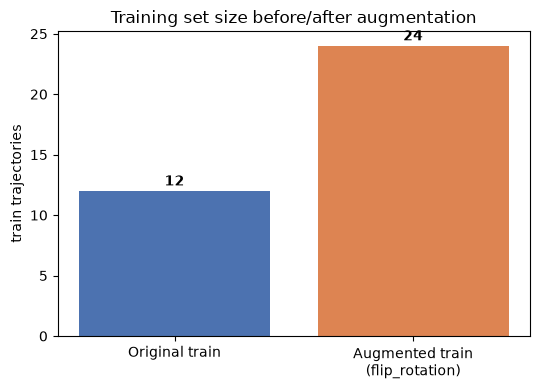

In [21]:
fig, ax = plt.subplots(figsize=(5.5, 4))
sizes = [len(train_ds), len(aug_ds)]
labels = ["Original train", "Augmented train\n(flip_rotation)"]
bars = ax.bar(labels, sizes, color=["#4C72B0", "#DD8452"])
for b, s in zip(bars, sizes):
    ax.annotate(str(s), (b.get_x() + b.get_width() / 2, s), textcoords="offset points",
               xytext=(0, 4), ha="center", fontweight="bold")
ax.set_ylabel("train trajectories")
ax.set_title("Training set size before/after augmentation")
plt.tight_layout()
plt.show()

## The model

In [22]:
MODEL_CLASS = AblationModelCustomRGB
MODEL_KWARGS = dict(
    d_model=D_MODEL, dropout=DROPOUT, cls_dropout=DROPOUT,
    freeze_visual_backbone=True,
    rgb_encoder_factory=lambda: VisualEncoderToggle("convnext_tiny", True, use_cbam=True),
)

set_seed(0)
probe_model = MODEL_CLASS(ABLATION_CONFIGS["full_model"], **MODEL_KWARGS).to(cfg["device"])
sample_batch = next(iter(val_loader))
profile = estimate_backbone_flops(probe_model, sample_batch, cfg["device"])
del probe_model
print(f"Model profile: {profile}")

/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_25661/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


Model profile: {'params_m': 32.47, 'flops_g': 39.026, 'latency_ms': 34.5}


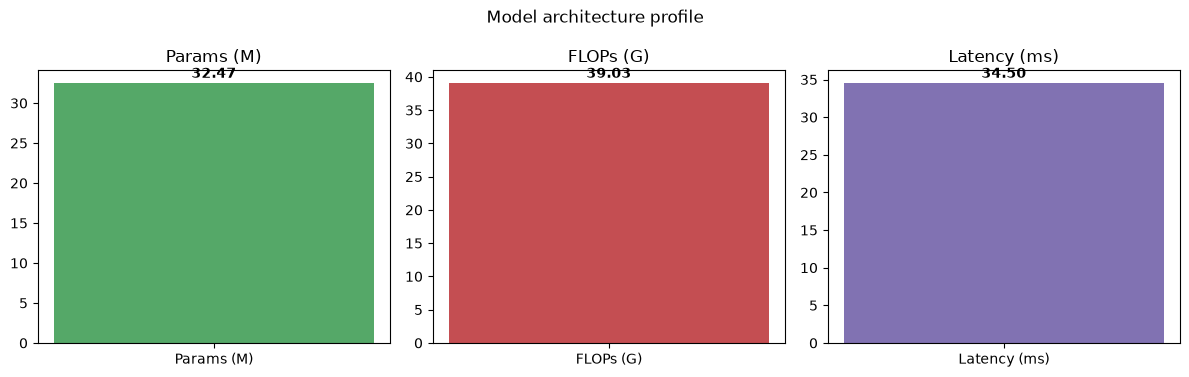

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
metrics = [("params_m", "Params (M)", "#55A868"), ("flops_g", "FLOPs (G)", "#C44E52"),
          ("latency_ms", "Latency (ms)", "#8172B2")]
for ax, (key, label, color) in zip(axes, metrics):
    val = profile.get(key)
    ax.bar([label], [val], color=color)
    ax.annotate(f"{val:.2f}" if val is not None else "n/a", (0, val or 0),
               textcoords="offset points", xytext=(0, 4), ha="center", fontweight="bold")
    ax.set_title(label)
plt.suptitle("Model architecture profile")
plt.tight_layout()
plt.show()

In [24]:
ABLATION_OUT = RUNS / "05_ablation_study"
ABLATION_OUT.mkdir(parents=True, exist_ok=True)
print(f"ABLATION_OUT redirected to: {ABLATION_OUT}")


ABLATION_OUT redirected to: /Users/sjanani2073/Desktop/convscript/runs/05_ablation_study


## 1. Training helper 

In [25]:
def train_one_run(run_name, seed, config_key, model_class, model_kwargs,
                  loader_train, loader_calib, loader_val, out_dir):
    set_seed(seed)
    run_dir = out_dir / f"{run_name}_seed{seed}" / f"seed_{seed}"
    run_dir.mkdir(parents=True, exist_ok=True)

    model = model_class(ABLATION_CONFIGS[config_key], **model_kwargs).to(cfg["device"])
    uncertainty_loss = UncertaintyWeightedLoss(n_tasks=3).to(cfg["device"])

    visual_backbone_ids = {id(p) for p in list(model.rgb_encoder.backbone.parameters()) +
                                          list(model.ir_encoder.backbone.parameters())}
    other_params = [p for p in model.parameters() if id(p) not in visual_backbone_ids]
    optimizer = AdamW([
        {"params": other_params, "lr": cfg["lr"]},
        {"params": list(model.rgb_encoder.backbone.parameters()) + list(model.ir_encoder.backbone.parameters()),
         "lr": cfg["lr_finetune"]},
        {"params": uncertainty_loss.parameters(), "lr": cfg["lr"]},
    ], weight_decay=cfg["weight_decay"])
    scheduler = CosineAnnealingLR(optimizer, T_max=cfg["epochs"])

    print(f"  --- {run_name} (config={config_key}) seed={seed} ---")
    best_f1, best_metrics, best_state, best_epoch = 0.0, None, None, None
    history = []
    for epoch in range(1, cfg["epochs"] + 1):
        if epoch == 6:
            model.unfreeze_visual_last_n(1)
        elif epoch == 8:
            model.unfreeze_visual_last_n(2)
        elif epoch == 12:
            model.unfreeze_visual_full()

        train_m = run_epoch(model, uncertainty_loss, loader_train, optimizer, cfg, train=True)
        thr = get_calibrated_threshold(model, uncertainty_loss, loader_calib, cfg)
        val_m = run_epoch(model, uncertainty_loss, loader_val, optimizer, cfg, train=False, threshold=thr)
        scheduler.step()
        history.append({"epoch": epoch, "train_f1": train_m["f1"], "train_loss": train_m.get("loss"),
                        "val_f1": val_m["f1"], "val_auc": val_m["auc"], "val_mae": val_m["mae"],
                        "threshold": thr})

        is_best = val_m["f1"] > best_f1
        if is_best:
            best_f1 = val_m["f1"]; best_metrics = val_m; best_epoch = epoch
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        star = " *" if is_best else ""
        print(f"    epoch {epoch:>2}/{cfg['epochs']}  train_loss={train_m.get('loss', float('nan')):.4f} "
             f"train_F1={train_m['f1']:.4f}  |  val_F1={val_m['f1']:.4f} val_AUC={val_m['auc']:.4f} "
             f"val_MAE={val_m['mae']:.4f} thr={thr:.2f}{star}")

    torch.save(best_state, run_dir / "model_state.pt")
    with open(run_dir / "history.json", "w") as f:
        json.dump(history, f, indent=2, default=str)
    print(f"  [{run_name} seed={seed}] BEST @ epoch {best_epoch}: val F1={best_metrics['f1']:.4f} "
         f"AUC={best_metrics['auc']:.4f} MAE={best_metrics['mae']:.4f} (thr={best_metrics['threshold']})\n")
    return best_metrics, history


## 2. Ensemble evaluation helper

In [26]:
def collect_group_probs_valonly(prefix, seeds, config_key, out_dir, model_class, model_kwargs,
                                loader_calib, loader_val):
    calib_probs, val_probs, calib_labels, val_labels = [], [], None, None
    for seed in seeds:
        state_path = out_dir / f"{prefix}_seed{seed}" / f"seed_{seed}" / "model_state.pt"
        if not state_path.exists():
            print(f"  [skip] no checkpoint for {prefix} seed={seed}")
            continue
        model = model_class(ABLATION_CONFIGS[config_key], **model_kwargs).to(cfg["device"])
        model.load_state_dict(torch.load(state_path, map_location=cfg["device"]))
        uncertainty_loss = UncertaintyWeightedLoss(n_tasks=3).to(cfg["device"])
        c_p, c_l, _, _ = collect_probs_labels(model, uncertainty_loss, loader_calib, cfg)
        v_p, v_l, _, _ = collect_probs_labels(model, uncertainty_loss, loader_val, cfg)
        calib_probs.append(c_p); val_probs.append(v_p)
        calib_labels, val_labels = c_l, v_l
    return {"calib_probs": calib_probs, "val_probs": val_probs,
           "calib_labels": calib_labels, "val_labels": val_labels}


def ensemble_eval_valonly(group):
    n = len(group["calib_probs"])
    if n == 0:
        return {"n_seeds": 0, "val_f1": float("nan"), "val_auc": float("nan")}
    w = np.ones(n) / n
    avg_calib = np.tensordot(w, np.stack(group["calib_probs"]), axes=1)
    avg_val   = np.tensordot(w, np.stack(group["val_probs"]),   axes=1)
    threshold, _ = calibrate_threshold(avg_calib[:, 1].tolist(), group["calib_labels"])
    val_preds = (avg_val[:, 1] >= threshold).astype(int).tolist()
    val_f1 = f1_score(group["val_labels"], val_preds, average="binary", zero_division=0)
    val_macro_f1 = f1_score(group["val_labels"], val_preds, average="macro", zero_division=0)
    val_acc = accuracy_score(group["val_labels"], val_preds)
    try:
        val_auc = roc_auc_score(group["val_labels"], avg_val[:, 1])
    except ValueError:
        val_auc = float("nan")
    return {"n_seeds": n, "threshold": threshold, "val_f1": round(float(val_f1), 4),
           "val_macro_f1": round(float(val_macro_f1), 4), "val_accuracy": round(float(val_acc), 4),
           "val_auc": round(float(val_auc), 4), "val_preds": val_preds,
           "val_probs_pos": avg_val[:, 1].tolist(), "val_labels": group["val_labels"]}


## 3. Profile all 7 configs (params / FLOPs / latency, architecture-only)

In [27]:
CONFIG_ORDER = ["baseline_a_early", "baseline_b_late", "ablation_1_no_cbam",
               "ablation_2_no_cross_attn", "ablation_3_lstm_not_transformer",
               "ablation_4_mean_impute_not_grud", "full_model"]
CONFIG_LABELS = {
    "baseline_a_early": "Baseline A\n(early fusion)",
    "baseline_b_late": "Baseline B\n(late fusion)",
    "ablation_1_no_cbam": "Ablation 1\n(no CBAM)",
    "ablation_2_no_cross_attn": "Ablation 2\n(no cross-attn)",
    "ablation_3_lstm_not_transformer": "Ablation 3\n(LSTM not Transformer)",
    "ablation_4_mean_impute_not_grud": "Ablation 4\n(mean-impute not GRU-D)",
    "full_model": "Full Model",
}

profiles = {}
for config_key in CONFIG_ORDER:
    set_seed(0)
    probe_model = MODEL_CLASS(ABLATION_CONFIGS[config_key], **MODEL_KWARGS).to(cfg["device"])
    profiles[config_key] = estimate_backbone_flops(probe_model, sample_batch, cfg["device"])
    del probe_model
    print(f"  {config_key:<35} {profiles[config_key]}")


  baseline_a_early                    {'params_m': 32.13, 'flops_g': 39.021, 'latency_ms': 35.3}
  baseline_b_late                     {'params_m': 32.22, 'flops_g': 39.022, 'latency_ms': 36.7}


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_25661/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  ablation_1_no_cbam                  {'params_m': 32.27, 'flops_g': 39.022, 'latency_ms': 33.9}
  ablation_2_no_cross_attn            {'params_m': 32.47, 'flops_g': 39.026, 'latency_ms': 33.0}
  ablation_3_lstm_not_transformer     {'params_m': 32.34, 'flops_g': 39.025, 'latency_ms': 34.7}
  ablation_4_mean_impute_not_grud     {'params_m': 32.47, 'flops_g': 39.026, 'latency_ms': 35.0}
  full_model                          {'params_m': 32.47, 'flops_g': 39.026, 'latency_ms': 34.5}


## 4. Train

In [28]:
import traceback

ABLATION_SEEDS = [0, 1, 2, 3, 4, 5]

all_results = {} 

for config_key in CONFIG_ORDER:
    print("=" * 100)
    print(f"CONFIG: {config_key}  ({ABLATION_CONFIGS[config_key]})")
    print("=" * 100)
    seed_f1s, histories, failures = [], {}, []
    for seed in ABLATION_SEEDS:
        try:
            best_metrics, history = train_one_run(config_key, seed, config_key, MODEL_CLASS, MODEL_KWARGS,
                                                  train_loader, train_loader_calib, val_loader, ABLATION_OUT)
            seed_f1s.append(best_metrics["f1"])
            histories[seed] = history
        except Exception as e:
            print(f"  [FAILED] {config_key} seed={seed}: {type(e).__name__}: {e}")
            traceback.print_exc()
            failures.append(f"seed={seed}: {type(e).__name__}: {e}")

    all_results[config_key] = {"seed_f1s": seed_f1s, "histories": histories, "failures": failures}
    if seed_f1s:
        print(f">>> {config_key}: {len(seed_f1s)} seeds, mean val F1 = {np.mean(seed_f1s):.4f} "
             f"(std={np.std(seed_f1s):.4f})\n")


CONFIG: baseline_a_early  ({'fusion_type': 'early', 'use_cbam': False, 'use_cross_attn': False, 'temporal_type': 'lstm', 'missing_handling': 'mean'})
  --- baseline_a_early (config=baseline_a_early) seed=0 ---
    epoch  1/30  train_loss=2.2463 train_F1=0.2727  |  val_F1=0.6667 val_AUC=0.2778 val_MAE=2.1659 thr=0.10 *
    epoch  2/30  train_loss=1.5005 train_F1=0.7273  |  val_F1=0.6667 val_AUC=0.4722 val_MAE=2.1680 thr=0.10
    epoch  3/30  train_loss=1.7230 train_F1=0.6207  |  val_F1=0.6667 val_AUC=0.4444 val_MAE=2.1654 thr=0.51
    epoch  4/30  train_loss=2.5365 train_F1=0.6250  |  val_F1=0.6667 val_AUC=0.4444 val_MAE=2.1657 thr=0.10
    epoch  5/30  train_loss=1.4492 train_F1=0.7429  |  val_F1=0.2222 val_AUC=0.4167 val_MAE=2.1636 thr=0.53
    epoch  6/30  train_loss=2.5157 train_F1=0.4286  |  val_F1=0.6667 val_AUC=0.4167 val_MAE=2.1613 thr=0.10
    epoch  7/30  train_loss=1.6735 train_F1=0.6667  |  val_F1=0.6667 val_AUC=0.1389 val_MAE=2.1608 thr=0.10
    epoch  8/30  train_loss=2.48

/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_25661/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  --- ablation_1_no_cbam (config=ablation_1_no_cbam) seed=0 ---
    epoch  1/30  train_loss=2.5558 train_F1=0.6207  |  val_F1=0.6667 val_AUC=0.3333 val_MAE=2.1695 thr=0.10 *
    epoch  2/30  train_loss=1.5601 train_F1=0.7027  |  val_F1=0.6667 val_AUC=0.2500 val_MAE=2.1791 thr=0.10
    epoch  3/30  train_loss=2.4582 train_F1=0.6471  |  val_F1=0.7059 val_AUC=0.5556 val_MAE=2.1591 thr=0.64 *
    epoch  4/30  train_loss=3.1329 train_F1=0.5926  |  val_F1=0.6667 val_AUC=0.2778 val_MAE=2.1805 thr=0.62
    epoch  5/30  train_loss=2.0781 train_F1=0.6061  |  val_F1=0.6667 val_AUC=0.4167 val_MAE=2.1753 thr=0.57
    epoch  6/30  train_loss=2.6905 train_F1=0.5517  |  val_F1=0.6250 val_AUC=0.5833 val_MAE=2.1709 thr=0.66
    epoch  7/30  train_loss=2.6746 train_F1=0.5926  |  val_F1=0.6667 val_AUC=0.5000 val_MAE=2.1951 thr=0.10
    epoch  8/30  train_loss=3.0381 train_F1=0.5000  |  val_F1=0.6667 val_AUC=0.2500 val_MAE=2.2097 thr=0.62
    epoch  9/30  train_loss=1.3215 train_F1=0.7429  |  val_F1=0.6250

/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_25661/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  --- ablation_1_no_cbam (config=ablation_1_no_cbam) seed=1 ---
    epoch  1/30  train_loss=2.7012 train_F1=0.5385  |  val_F1=0.4615 val_AUC=0.5000 val_MAE=2.1878 thr=0.60 *
    epoch  2/30  train_loss=1.8817 train_F1=0.5517  |  val_F1=0.6667 val_AUC=0.4722 val_MAE=2.2279 thr=0.61 *
    epoch  3/30  train_loss=1.8920 train_F1=0.7778  |  val_F1=0.6667 val_AUC=0.6667 val_MAE=2.2134 thr=0.55
    epoch  4/30  train_loss=2.2196 train_F1=0.7097  |  val_F1=0.6154 val_AUC=0.6667 val_MAE=2.2150 thr=0.67
    epoch  5/30  train_loss=1.8521 train_F1=0.7273  |  val_F1=0.7059 val_AUC=0.6111 val_MAE=2.2177 thr=0.65 *
    epoch  6/30  train_loss=2.1935 train_F1=0.5806  |  val_F1=0.6667 val_AUC=0.6944 val_MAE=2.2043 thr=0.74
    epoch  7/30  train_loss=2.2592 train_F1=0.6471  |  val_F1=0.7500 val_AUC=0.6667 val_MAE=2.2074 thr=0.66 *
    epoch  8/30  train_loss=2.4935 train_F1=0.6875  |  val_F1=0.6154 val_AUC=0.6111 val_MAE=2.2085 thr=0.69
    epoch  9/30  train_loss=1.6224 train_F1=0.6471  |  val_F1=0.

...

  --- full_model (config=full_model) seed=3 ---
    epoch  1/30  train_loss=2.2894 train_F1=0.6250  |  val_F1=0.6250 val_AUC=0.3611 val_MAE=2.1871 thr=0.44 *
    epoch  2/30  train_loss=2.6357 train_F1=0.6250  |  val_F1=0.0000 val_AUC=0.3056 val_MAE=2.2298 thr=0.48
    epoch  3/30  train_loss=2.2864 train_F1=0.5000  |  val_F1=0.4286 val_AUC=0.2778 val_MAE=2.1631 thr=0.48
    epoch  4/30  train_loss=2.0549 train_F1=0.4545  |  val_F1=0.7059 val_AUC=0.6389 val_MAE=2.1365 thr=0.44 *
    epoch  5/30  train_loss=1.4074 train_F1=0.6000  |  val_F1=0.6154 val_AUC=0.6111 val_MAE=2.1370 thr=0.48
    epoch  6/30  train_loss=1.9135 train_F1=0.6154  |  val_F1=0.6667 val_AUC=0.5833 val_MAE=2.1192 thr=0.53
    epoch  7/30  train_loss=2.2696 train_F1=0.4444  |  val_F1=0.2222 val_AUC=0.4722 val_MAE=2.1562 thr=0.64
    epoch  8/30  train_loss=2.1086 train_F1=0.3636  |  val_F1=0.6667 val_AUC=0.5833 val_MAE=2.1448 thr=0.59
    epoch  9/30  train_loss=2.1930 train_F1=0.4444  |  val_F1=0.2222 val_AUC=0.3611 

/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_25661/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  --- full_model (config=full_model) seed=4 ---
    epoch  1/30  train_loss=2.4096 train_F1=0.5517  |  val_F1=0.6667 val_AUC=0.5556 val_MAE=2.1667 thr=0.10 *
    epoch  2/30  train_loss=1.8409 train_F1=0.6250  |  val_F1=0.5882 val_AUC=0.6389 val_MAE=2.1667 thr=0.50
    epoch  3/30  train_loss=2.0331 train_F1=0.6250  |  val_F1=0.5882 val_AUC=0.3611 val_MAE=2.1667 thr=0.51
    epoch  4/30  train_loss=1.7255 train_F1=0.5714  |  val_F1=0.7143 val_AUC=0.7222 val_MAE=2.1667 thr=0.54 *
    epoch  5/30  train_loss=1.4158 train_F1=0.7647  |  val_F1=0.6667 val_AUC=0.7500 val_MAE=2.1667 thr=0.49
    epoch  6/30  train_loss=1.6804 train_F1=0.6875  |  val_F1=0.6667 val_AUC=0.4444 val_MAE=2.1667 thr=0.60
    epoch  7/30  train_loss=1.8316 train_F1=0.7879  |  val_F1=0.7059 val_AUC=0.6111 val_MAE=2.1667 thr=0.56
    epoch  8/30  train_loss=2.3876 train_F1=0.6452  |  val_F1=0.7059 val_AUC=0.6667 val_MAE=2.1667 thr=0.60
    epoch  9/30  train_loss=2.5461 train_F1=0.6250  |  val_F1=0.7500 val_AUC=0.6111 

/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_25661/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  --- full_model (config=full_model) seed=5 ---
    epoch  1/30  train_loss=2.7157 train_F1=0.4000  |  val_F1=0.6667 val_AUC=0.5833 val_MAE=2.1616 thr=0.51 *
    epoch  2/30  train_loss=2.0782 train_F1=0.6061  |  val_F1=0.6667 val_AUC=0.7222 val_MAE=2.1259 thr=0.10
    epoch  3/30  train_loss=1.5135 train_F1=0.6875  |  val_F1=0.7500 val_AUC=0.6389 val_MAE=2.1142 thr=0.63 *
    epoch  4/30  train_loss=2.3028 train_F1=0.5385  |  val_F1=0.7500 val_AUC=0.8056 val_MAE=2.1465 thr=0.65
    epoch  5/30  train_loss=2.7013 train_F1=0.5806  |  val_F1=0.6667 val_AUC=0.9722 val_MAE=2.1308 thr=0.68
    epoch  6/30  train_loss=2.2973 train_F1=0.6452  |  val_F1=0.7500 val_AUC=0.9167 val_MAE=2.1382 thr=0.68
    epoch  7/30  train_loss=0.9142 train_F1=0.7692  |  val_F1=0.7500 val_AUC=0.5833 val_MAE=2.1308 thr=0.69
    epoch  8/30  train_loss=2.3745 train_F1=0.7059  |  val_F1=0.6667 val_AUC=0.6389 val_MAE=2.1260 thr=0.69
    epoch  9/30  train_loss=1.8086 train_F1=0.6667  |  val_F1=0.7143 val_AUC=0.7778 

## 5. Per-config training curves 

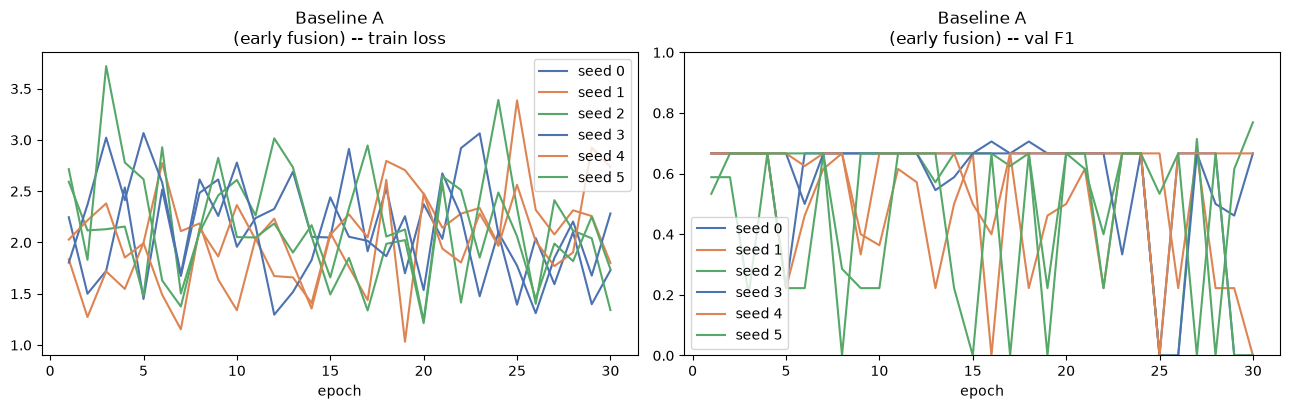

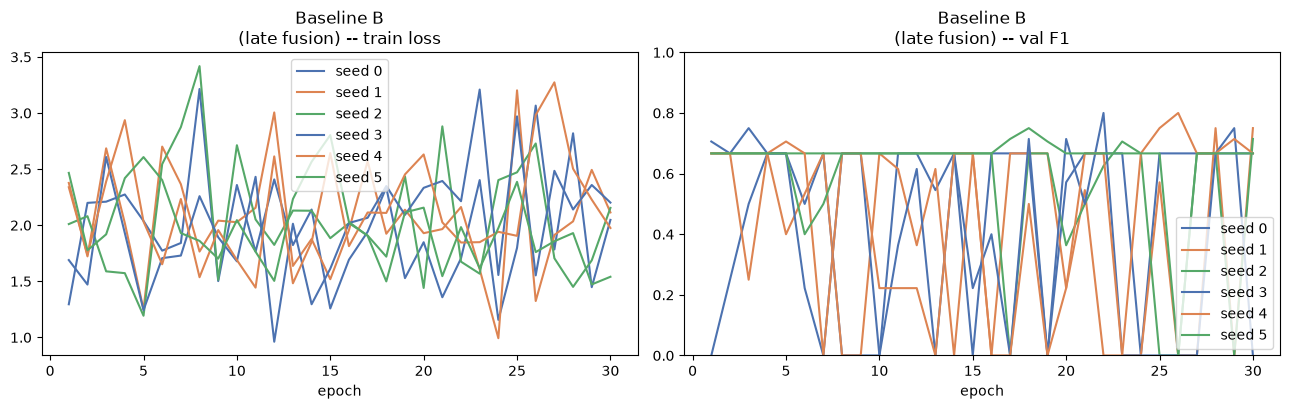

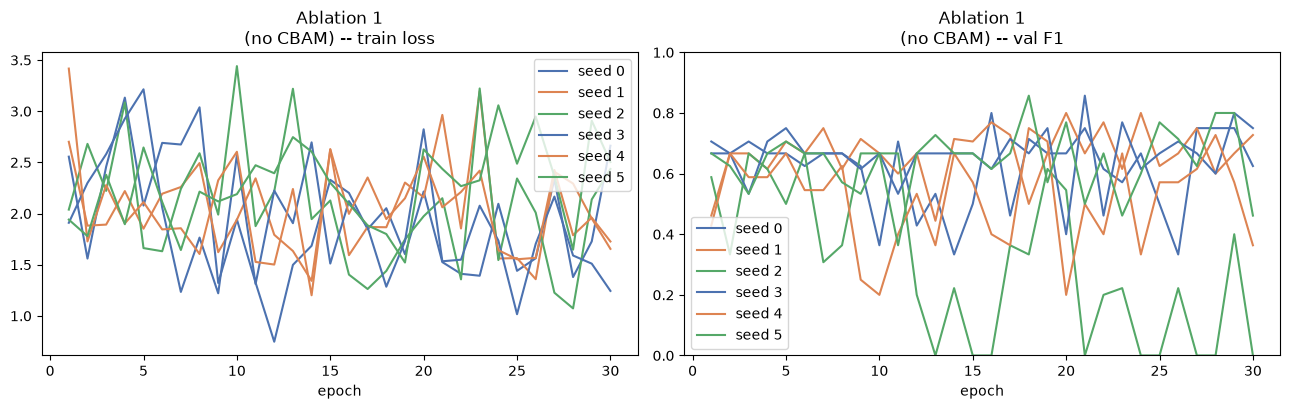

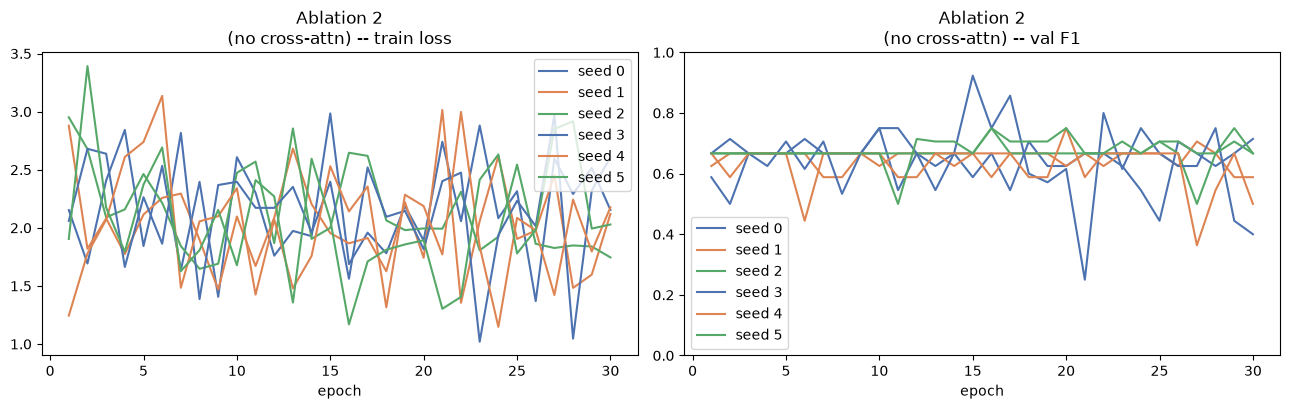

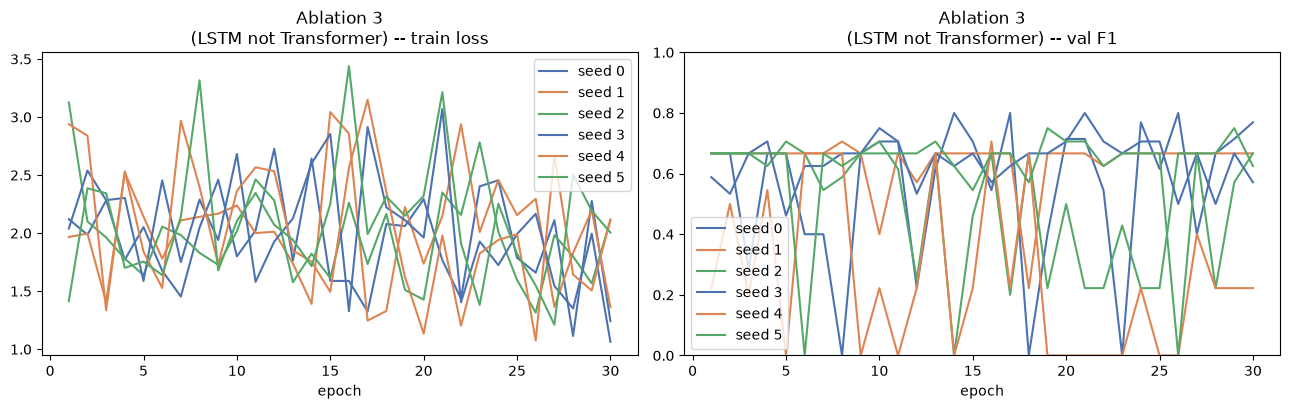

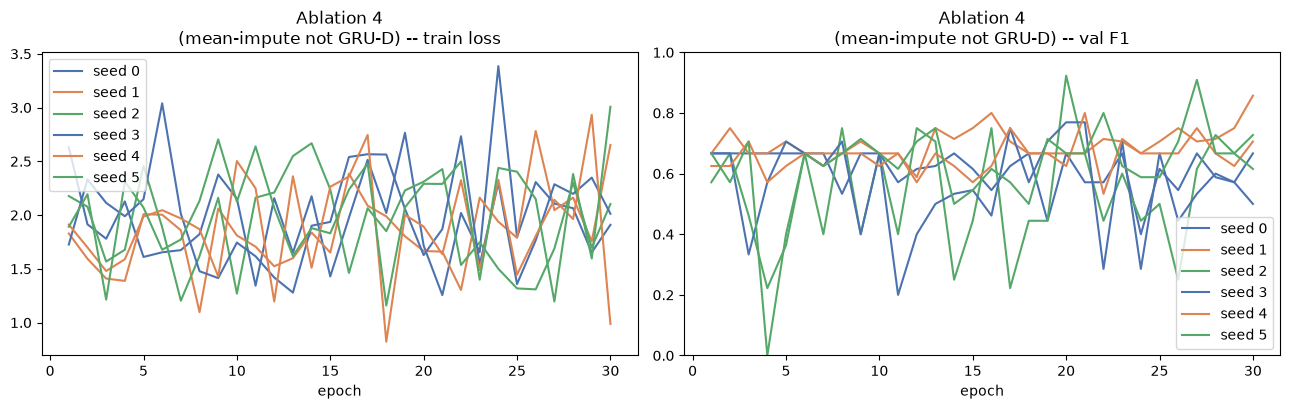

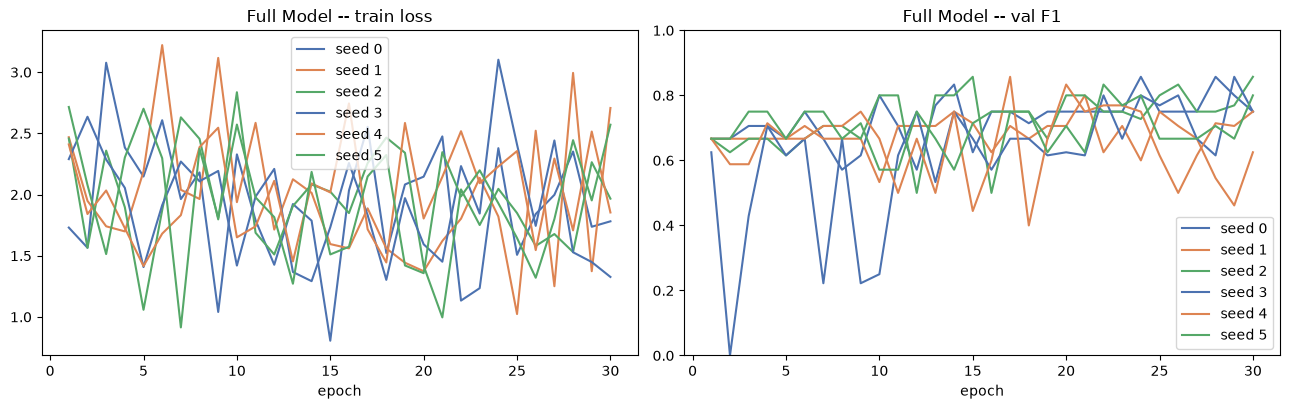

In [29]:
SEED_COLORS = ["#4C72B0", "#DD8452", "#55A868"]

for config_key in CONFIG_ORDER:
    histories = all_results[config_key]["histories"]
    if not histories:
        continue
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    for i, (seed, hist) in enumerate(histories.items()):
        epochs = [h["epoch"] for h in hist]
        color = SEED_COLORS[i % len(SEED_COLORS)]
        axes[0].plot(epochs, [h["train_loss"] for h in hist], color=color, label=f"seed {seed}")
        axes[1].plot(epochs, [h["val_f1"] for h in hist], color=color, label=f"seed {seed}")
    axes[0].set_title(f"{CONFIG_LABELS[config_key]} -- train loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
    axes[1].set_title(f"{CONFIG_LABELS[config_key]} -- val F1"); axes[1].set_xlabel("epoch"); axes[1].legend()
    axes[1].set_ylim(0, 1)
    plt.tight_layout(); plt.show()


## 6. Ensemble evaluation 

In [30]:
ensemble_results = {}
for config_key in CONFIG_ORDER:
    group = collect_group_probs_valonly(config_key, ABLATION_SEEDS, config_key, ABLATION_OUT,
                                        MODEL_CLASS, MODEL_KWARGS, train_loader_calib, val_loader)
    ensemble_results[config_key] = ensemble_eval_valonly(group)
    r = ensemble_results[config_key]
    print(f"  {config_key:<35} ensemble val F1={r['val_f1']:.4f}  AUC={r['val_auc']:.4f}  "
         f"macroF1={r.get('val_macro_f1', float('nan')):.4f}  acc={r.get('val_accuracy', float('nan')):.4f}")


  baseline_a_early                    ensemble val F1=0.6667  AUC=0.4722  macroF1=0.3333  acc=0.5000
  baseline_b_late                     ensemble val F1=0.7059  AUC=0.5556  macroF1=0.4958  acc=0.5833


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_25661/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  ablation_1_no_cbam                  ensemble val F1=0.8000  AUC=0.7500  macroF1=0.7333  acc=0.7500


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_25661/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  ablation_2_no_cross_attn            ensemble val F1=0.6667  AUC=1.0000  macroF1=0.3333  acc=0.5000
  ablation_3_lstm_not_transformer     ensemble val F1=0.8571  AUC=0.6667  macroF1=0.8286  acc=0.8333


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_25661/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  ablation_4_mean_impute_not_grud     ensemble val F1=0.8571  AUC=0.9722  macroF1=0.8286  acc=0.8333


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_25661/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  full_model                          ensemble val F1=0.8000  AUC=0.9444  macroF1=0.7333  acc=0.7500


## 7. Ranked comparison 

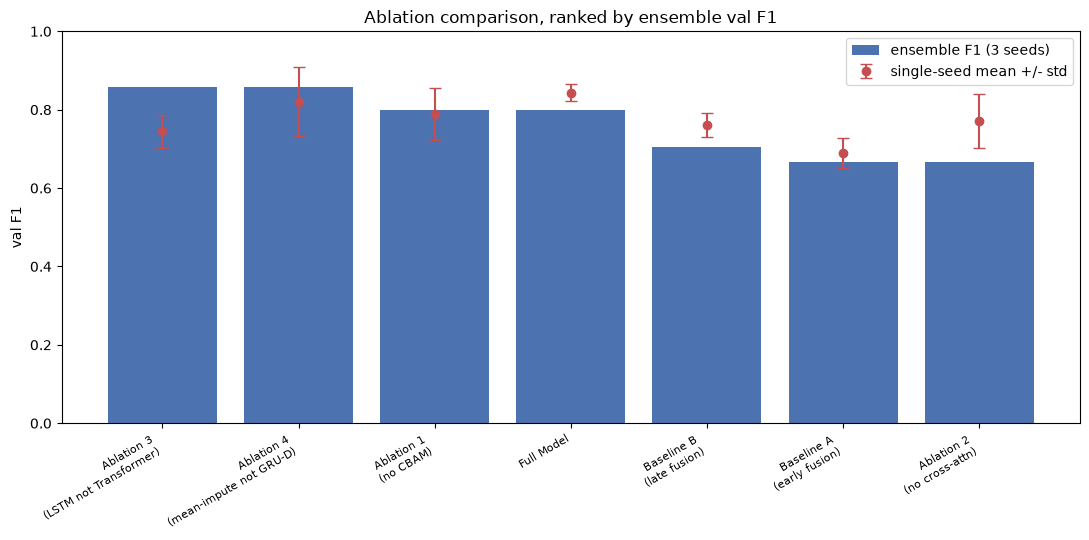

Ranked (by ensemble val F1):
  Ablation 3 (LSTM not Transformer)        ensemble=0.8571  single-seed mean=0.7446+/-0.0422
  Ablation 4 (mean-impute not GRU-D)       ensemble=0.8571  single-seed mean=0.8209+/-0.0880
  Ablation 1 (no CBAM)                     ensemble=0.8000  single-seed mean=0.7885+/-0.0658
  Full Model                               ensemble=0.8000  single-seed mean=0.8436+/-0.0214
  Baseline B (late fusion)                 ensemble=0.7059  single-seed mean=0.7607+/-0.0305
  Baseline A (early fusion)                ensemble=0.6667  single-seed mean=0.6903+/-0.0381
  Ablation 2 (no cross-attn)               ensemble=0.6667  single-seed mean=0.7715+/-0.0697


In [31]:
ranked_keys = sorted(CONFIG_ORDER, key=lambda k: -ensemble_results[k]["val_f1"])

fig, ax = plt.subplots(figsize=(11, 5.5))
means = [np.mean(all_results[k]["seed_f1s"]) if all_results[k]["seed_f1s"] else 0 for k in ranked_keys]
stds  = [np.std(all_results[k]["seed_f1s"]) if all_results[k]["seed_f1s"] else 0 for k in ranked_keys]
ensembles = [ensemble_results[k]["val_f1"] for k in ranked_keys]
labels = [CONFIG_LABELS[k] for k in ranked_keys]
x = np.arange(len(ranked_keys))

ax.bar(x, ensembles, color="#4C72B0", label="ensemble F1 (3 seeds)")
ax.errorbar(x, means, yerr=stds, fmt="o", color="#C44E52", capsize=4, label="single-seed mean +/- std")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("val F1"); ax.set_ylim(0, 1)
ax.set_title("Ablation comparison, ranked by ensemble val F1")
ax.legend()
plt.tight_layout(); plt.show()

print("Ranked (by ensemble val F1):")
for k in ranked_keys:
    print(f"  {CONFIG_LABELS[k].replace(chr(10), ' '):<40} ensemble={ensemble_results[k]['val_f1']:.4f}  "
         f"single-seed mean={np.mean(all_results[k]['seed_f1s']):.4f}+/-{np.std(all_results[k]['seed_f1s']):.4f}")


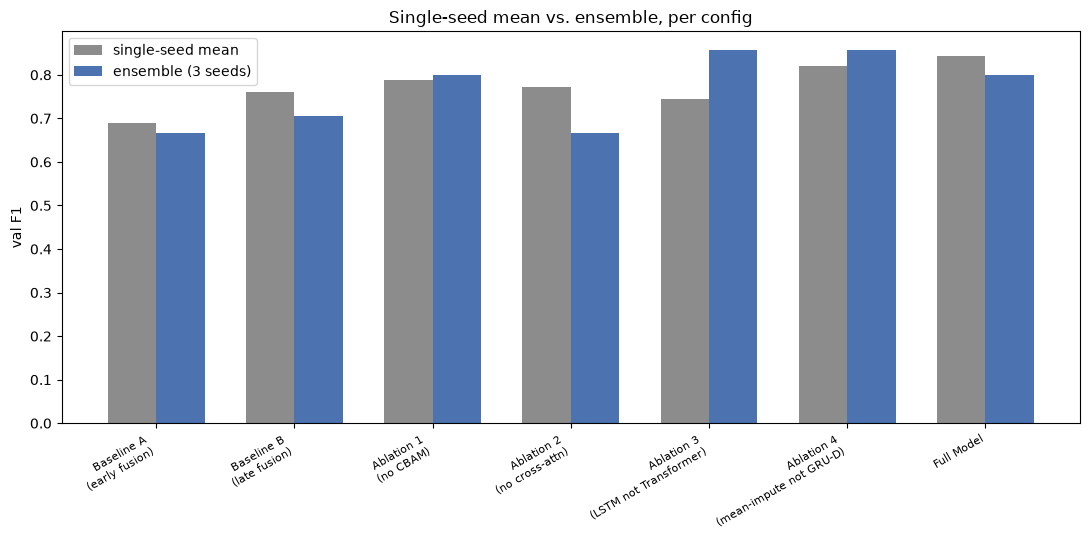

Ensembling delta (ensemble - single-seed mean):
  baseline_a_early                    -0.0236
  baseline_b_late                     -0.0548
  ablation_1_no_cbam                  +0.0115
  ablation_2_no_cross_attn            -0.1048
  ablation_3_lstm_not_transformer     +0.1125
  ablation_4_mean_impute_not_grud     +0.0362
  full_model                          -0.0436


In [32]:
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(CONFIG_ORDER))
width = 0.35
single_means = [np.mean(all_results[k]["seed_f1s"]) for k in CONFIG_ORDER]
ensemble_vals = [ensemble_results[k]["val_f1"] for k in CONFIG_ORDER]
ax.bar(x - width/2, single_means, width, label="single-seed mean", color="#8C8C8C")
ax.bar(x + width/2, ensemble_vals, width, label="ensemble (3 seeds)", color="#4C72B0")
ax.set_xticks(x); ax.set_xticklabels([CONFIG_LABELS[k] for k in CONFIG_ORDER], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("val F1"); ax.set_title("Single-seed mean vs. ensemble, per config")
ax.legend()
plt.tight_layout(); plt.show()

print("Ensembling delta (ensemble - single-seed mean):")
for k in CONFIG_ORDER:
    delta = ensemble_results[k]["val_f1"] - np.mean(all_results[k]["seed_f1s"])
    print(f"  {k:<35} {delta:+.4f}")


## 8. Per-seed F1 spread across configs 

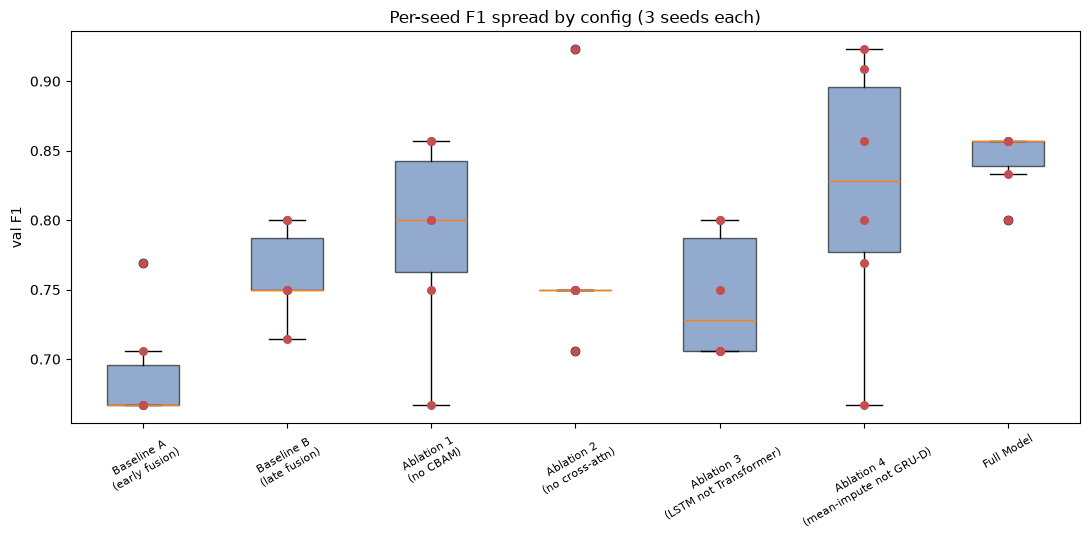

In [33]:
fig, ax = plt.subplots(figsize=(11, 5.5))
data = [all_results[k]["seed_f1s"] for k in CONFIG_ORDER]
bp = ax.boxplot(data, tick_labels=[CONFIG_LABELS[k] for k in CONFIG_ORDER], patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#4C72B0"); patch.set_alpha(0.6)
for i, k in enumerate(CONFIG_ORDER):
    ys = all_results[k]["seed_f1s"]
    ax.scatter([i + 1] * len(ys), ys, color="#C44E52", zorder=3, s=30)
ax.set_ylabel("val F1"); ax.set_title("Per-seed F1 spread by config (3 seeds each)")
ax.tick_params(axis="x", rotation=30)
plt.setp(ax.get_xticklabels(), fontsize=8)
plt.tight_layout(); plt.show()


## 9. Component contribution 

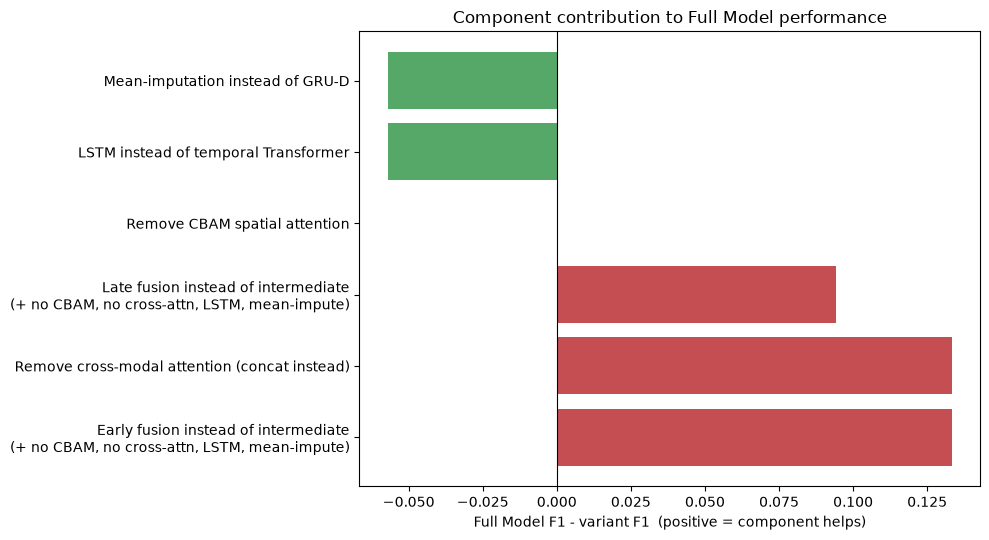

  Early fusion instead of intermediate               delta=+0.1333  (helps)
  Remove cross-modal attention (concat instead)      delta=+0.1333  (helps)
  Late fusion instead of intermediate                delta=+0.0941  (helps)
  Remove CBAM spatial attention                      delta=+0.0000  (~no effect at this seed count)
  LSTM instead of temporal Transformer               delta=-0.0571  (hurts (or noise))
  Mean-imputation instead of GRU-D                   delta=-0.0571  (hurts (or noise))


In [34]:
full_f1 = ensemble_results["full_model"]["val_f1"]
component_labels = {
    "baseline_a_early": "Early fusion instead of intermediate\n(+ no CBAM, no cross-attn, LSTM, mean-impute)",
    "baseline_b_late": "Late fusion instead of intermediate\n(+ no CBAM, no cross-attn, LSTM, mean-impute)",
    "ablation_1_no_cbam": "Remove CBAM spatial attention",
    "ablation_2_no_cross_attn": "Remove cross-modal attention (concat instead)",
    "ablation_3_lstm_not_transformer": "LSTM instead of temporal Transformer",
    "ablation_4_mean_impute_not_grud": "Mean-imputation instead of GRU-D",
}
deltas = {k: full_f1 - ensemble_results[k]["val_f1"] for k in component_labels}
ranked_deltas = sorted(deltas.items(), key=lambda kv: -kv[1])

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = ["#C44E52" if d > 0 else "#55A868" for _, d in ranked_deltas]
ax.barh([component_labels[k] for k, _ in ranked_deltas], [d for _, d in ranked_deltas], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Full Model F1 - variant F1  (positive = component helps)")
ax.set_title("Component contribution to Full Model performance")
plt.tight_layout(); plt.show()

for k, d in ranked_deltas:
    verdict = "helps" if d > 0.01 else ("hurts (or noise)" if d < -0.01 else "~no effect at this seed count")
    print(f"  {component_labels[k].splitlines()[0]:<50} delta={d:+.4f}  ({verdict})")


## 10. Multi-metric radar chart 

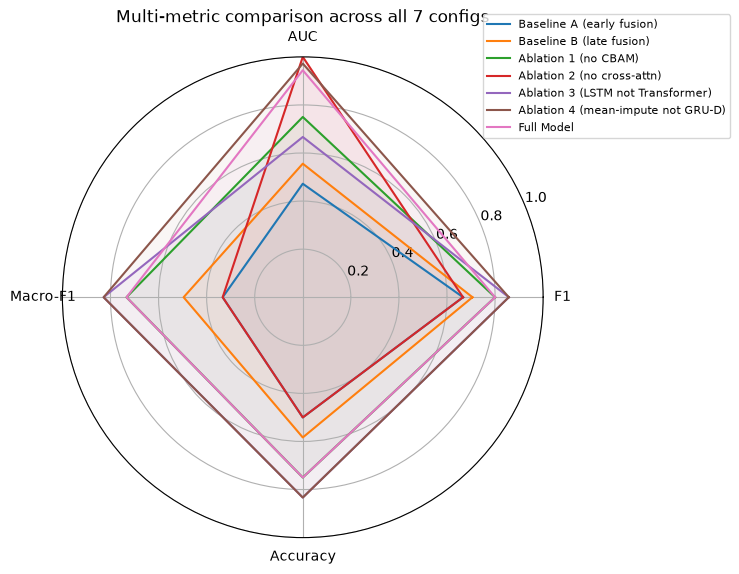

In [35]:
radar_metrics = ["val_f1", "val_auc", "val_macro_f1", "val_accuracy"]
radar_metric_labels = ["F1", "AUC", "Macro-F1", "Accuracy"]
angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})
cmap = plt.get_cmap("tab10")
for i, config_key in enumerate(CONFIG_ORDER):
    r = ensemble_results[config_key]
    values = [r.get(m, 0) or 0 for m in radar_metrics]
    values += values[:1]
    ax.plot(angles, values, label=CONFIG_LABELS[config_key].replace("\n", " "), color=cmap(i), linewidth=1.5)
    ax.fill(angles, values, color=cmap(i), alpha=0.05)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_metric_labels)
ax.set_ylim(0, 1)
ax.set_title("Multi-metric comparison across all 7 configs")
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=8)
plt.tight_layout(); plt.show()


## 11. Confusion matrices

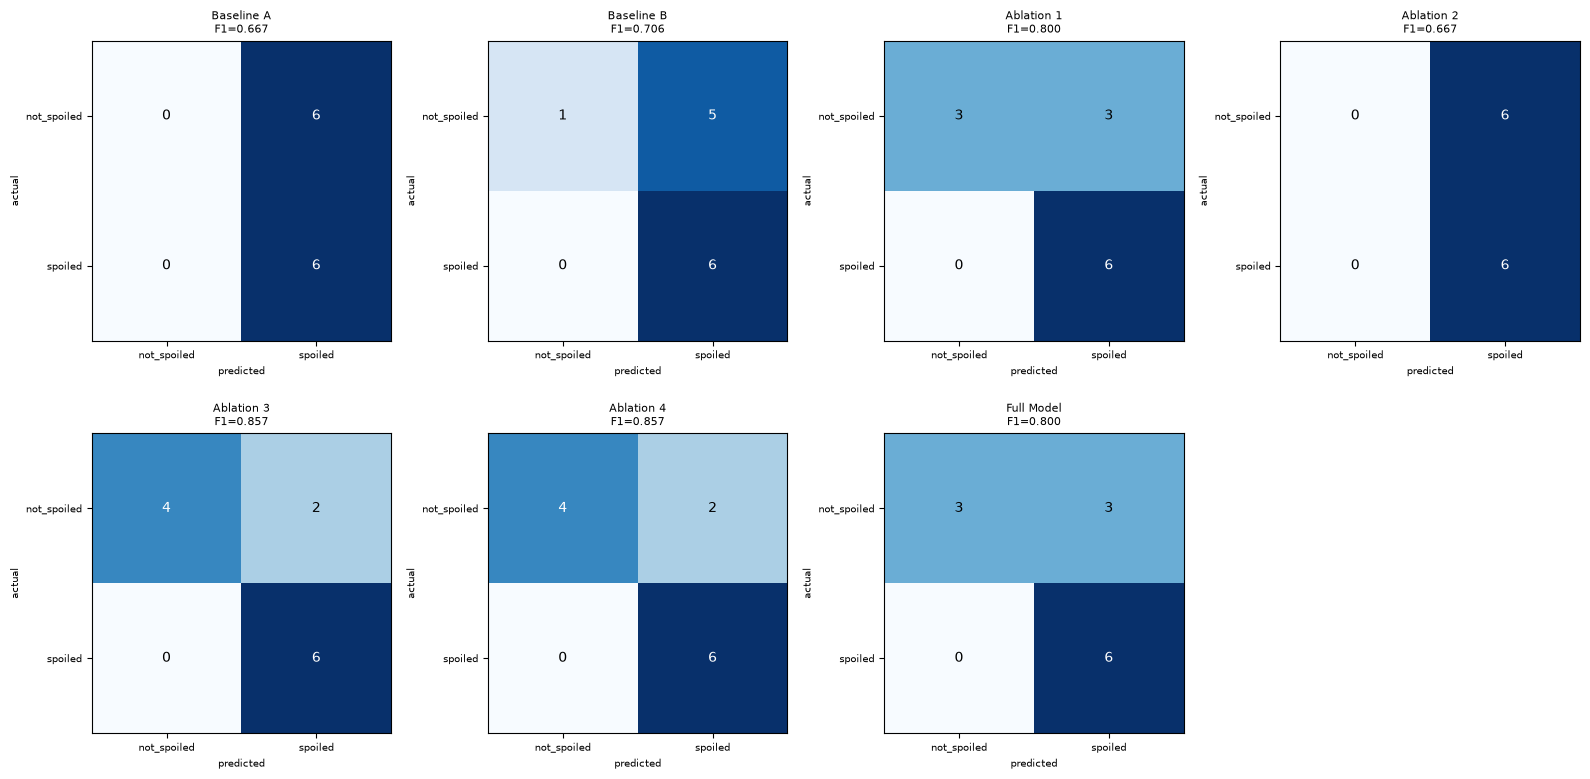

In [36]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, config_key in enumerate(CONFIG_ORDER):
    r = ensemble_results[config_key]
    cm = confusion_matrix(r["val_labels"], r["val_preds"], labels=[0, 1])
    im = axes[i].imshow(cm, cmap="Blues")
    axes[i].set_xticks([0, 1]); axes[i].set_xticklabels(["not_spoiled", "spoiled"], fontsize=7)
    axes[i].set_yticks([0, 1]); axes[i].set_yticklabels(["not_spoiled", "spoiled"], fontsize=7)
    axes[i].set_xlabel("predicted", fontsize=7); axes[i].set_ylabel("actual", fontsize=7)
    for r_i in range(2):
        for c_i in range(2):
            axes[i].text(c_i, r_i, cm[r_i, c_i], ha="center", va="center",
                        color="white" if cm[r_i, c_i] > cm.max() / 2 else "black", fontsize=10)
    axes[i].set_title(f"{CONFIG_LABELS[config_key].splitlines()[0]}\nF1={r['val_f1']:.3f}", fontsize=8)
for j in range(len(CONFIG_ORDER), len(axes)):
    axes[j].axis("off")
plt.tight_layout(); plt.show()


## 12. ROC curves 

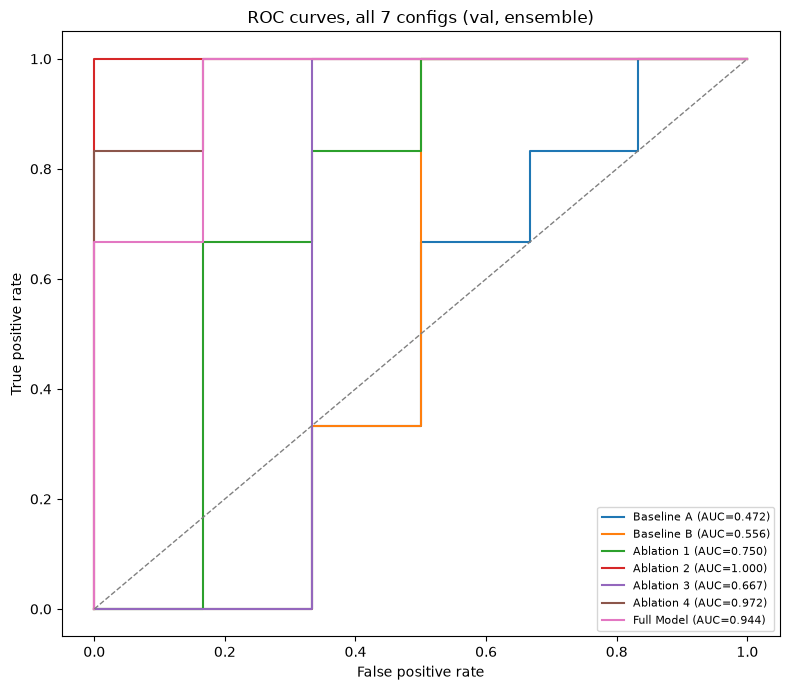

In [37]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 7))
cmap = plt.get_cmap("tab10")
for i, config_key in enumerate(CONFIG_ORDER):
    r = ensemble_results[config_key]
    fpr, tpr, _ = roc_curve(r["val_labels"], r["val_probs_pos"])
    ax.plot(fpr, tpr, color=cmap(i), label=f"{CONFIG_LABELS[config_key].splitlines()[0]} (AUC={r['val_auc']:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curves, all 7 configs (val, ensemble)")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()


## 13. Params / FLOPs / latency 

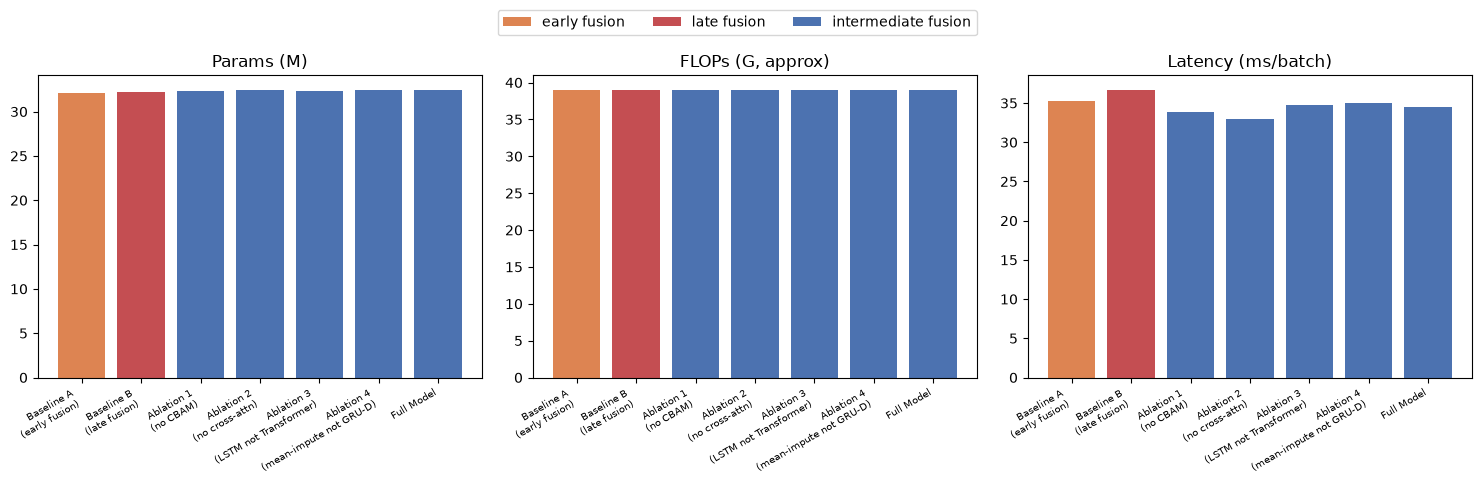

In [38]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metric_keys = ["params_m", "flops_g", "latency_ms"]
metric_titles = ["Params (M)", "FLOPs (G, approx)", "Latency (ms/batch)"]
colors_fusion = {"early": "#DD8452", "late": "#C44E52", "intermediate": "#4C72B0"}
for ax, mk, title in zip(axes, metric_keys, metric_titles):
    vals = [profiles[k].get(mk) or 0 for k in CONFIG_ORDER]
    bar_colors = [colors_fusion[ABLATION_CONFIGS[k]["fusion_type"]] for k in CONFIG_ORDER]
    ax.bar(range(len(CONFIG_ORDER)), vals, color=bar_colors)
    ax.set_xticks(range(len(CONFIG_ORDER)))
    ax.set_xticklabels([CONFIG_LABELS[k] for k in CONFIG_ORDER], rotation=30, ha="right", fontsize=7)
    ax.set_title(title)
legend_handles = [Patch(facecolor=c, label=f"{f} fusion") for f, c in colors_fusion.items()]
fig.legend(handles=legend_handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout(); plt.show()


## 14. Final summary table

In [40]:
import pandas as pd

rows = []
for config_key in CONFIG_ORDER:
    cfg_spec = ABLATION_CONFIGS[config_key]
    r = ensemble_results[config_key]
    f1s = all_results[config_key]["seed_f1s"]
    prof = profiles[config_key]
    rows.append({
        "Config": config_key,
        "Fusion": cfg_spec["fusion_type"],
        "CBAM": cfg_spec["use_cbam"],
        "Cross-attn": cfg_spec["use_cross_attn"],
        "Temporal": cfg_spec["temporal_type"],
        "Missing-handling": cfg_spec["missing_handling"],
        "Single-seed F1 (mean+/-std)": f"{np.mean(f1s):.4f}+/-{np.std(f1s):.4f}" if f1s else "n/a",
        "Ensemble F1": r["val_f1"],
        "Ensemble AUC": r["val_auc"],
        "Params(M)": prof["params_m"],
        "FLOPs(G)": prof["flops_g"],
        "Latency(ms)": prof["latency_ms"],
    })

summary_df = pd.DataFrame(rows).sort_values("Ensemble F1", ascending=False)
print(summary_df.to_string(index=False))


                         Config       Fusion  CBAM  Cross-attn    Temporal Missing-handling Single-seed F1 (mean+/-std)  Ensemble F1  Ensemble AUC  Params(M)  FLOPs(G)  Latency(ms)
ablation_3_lstm_not_transformer intermediate  True        True        lstm             grud             0.7446+/-0.0422       0.8571        0.6667      32.34    39.025         34.7
ablation_4_mean_impute_not_grud intermediate  True        True transformer             mean             0.8209+/-0.0880       0.8571        0.9722      32.47    39.026         35.0
             ablation_1_no_cbam intermediate False        True transformer             grud             0.7885+/-0.0658       0.8000        0.7500      32.27    39.022         33.9
                     full_model intermediate  True        True transformer             grud             0.8436+/-0.0214       0.8000        0.9444      32.47    39.026         34.5
                baseline_b_late         late False       False        lstm             mean    